# Reto: Preparación y Validación Reproducible de un Conjunto de Datos Industrial

### Objetivo General
Describir, sincronizar y optimizar un conjunto completo de imágenes TIFF y telemetría de un sistema de deposición láser.

### Estructura del Taller
- **Imágenes**: Múltiples frames del sensor (16 bits, formato TIFF)
- **Telemetría**: CSV con posiciones 3D, orientación, estado del láser y temperaturas
- **Desafío**: Sincronizar frames con registros del CSV y reducir datos sin perder información útil

### Integrantes
Junior Anchundia, Jeremy Garzon, Noelia Quishpe

## Definición directorio raíz del proyecto 

In [144]:
from pathlib import Path                # Manipulación orientada a objetos de rutas
CODE_DIR = Path.cwd().resolve()
PROJECT_ROOT = CODE_DIR.parent
DATA_DIR = PROJECT_ROOT / "Data"
UTILS_DIR = PROJECT_ROOT / "utils"

## Instalación de Dependencias

In [ ]:
%pip install -r "{ UTILS_DIR / "requirements.txt"}"

## Importaciones y Configuración

In [ ]:
# Importaciones de librerías fundamentales para procesamiento de datos e imágenes
import numpy as np                      # Computación numérica eficiente
import pandas as pd                     # Manipulación y análisis de datos tabulares
import matplotlib.pyplot as plt         # Visualización de datos
from mpl_toolkits.mplot3d import Axes3D # Gráficos 3D
import cv2                              # Procesamiento de imágenes
from PIL import Image                   # Lectura de imágenes
import tifffile                         # Lectura especializada de TIFF
import json                             # Serialización de metadatos
import os                               # Operaciones del sistema de archivos
import warnings
from datetime import datetime           # Manejo de fechas/horas
from concurrent.futures import ThreadPoolExecutor, as_completed

warnings.filterwarnings('ignore')

# Configuración de visualización
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print(f'NumPy versión: {np.__version__}')
print(f'Pandas versión: {pd.__version__}')
print(f'Matplotlib versión: {plt.matplotlib.__version__}')

NumPy versión: 2.5.3
Pandas versión: 3.0.6
Matplotlib versión: 3.11.2


## Configuración de Rutas

In [ ]:
# Ruta del archivo de datos (CSV con telemetría del sistema)
csv_path = DATA_DIR / "file.csv"

# Ruta de las imágenes (TIFFs de 16 bits del sensor)
images_dir = DATA_DIR / "images"

# Ruta de salida para resultados (CSV mejorado, registros JSON, figuras)
output_dir = DATA_DIR / "outputs"
output_dir.mkdir(parents=True, exist_ok=True)

# Directorio para imágenes procesadas
output_images_dir = output_dir / "imagenes_procesadas"
output_images_dir.mkdir(parents=True, exist_ok=True)

# Verificar disponibilidad de archivos
print(f'✓ CSV disponible: {csv_path.exists()}')
print(f'✓ Directorio de imágenes: {images_dir.exists()}')
print(f'✓ Directorio de salida: {output_dir}')

✓ CSV disponible: True
✓ Directorio de imágenes: True
✓ Directorio de salida: C:\Users\noeli\OneDrive\Documentos\CursoIA\Data\outputs


Como equipo, se plantea aplicar ciertos principios de la metodología **CRISP-DM** en el desarrollo del reto, adaptándolos al análisis, sincronización y reducción del conjunto de datos, ya que esto nos permitirá comprender de mejor manera el proceso **end-to-end** y fortalecer nuestro aprendizaje práctico de forma estructurada.

## Comprensión del problema

### Contexto

En la tecnología L-DED, un láser de alta potencia funde material metálico y lo deposita progresivamente para fabricar o reparar piezas, capa por capa.

### Problemática

La variación no controlada de la piscina fundida puede contribuir a la aparición de **deformaciones, porosidad, falta de fusión y otras discontinuidades** en el material.

### Necesidad de análisis

- Disponer simultáneamente de **imágenes del proceso y datos de telemetría** permite estudiar el comportamiento de la piscina fundida junto con las condiciones de operación del sistema.

- El proceso genera dos fuentes principales de información: **imágenes capturadas por la cámara para observar la piscina fundida y datos de telemetría** que registran las condiciones de operación del sistema.

- El reto consiste en integrar y sincronizar ambas fuentes, garantizando su consistencia y reduciendo su volumen de almacenamiento sin perder información relevante.

## Comprensión y Preparación de los Datos

Para estos apartados se seguirá el orden establecido en el reto, ya que lo solicitado estructura de manera progresiva el proceso de **exploración, transformación y preparación de los datos**. Esto facilita el análisis conjunto de las imágenes TIFF y el CSV, así como la aplicación práctica de los conocimientos adquiridos en la semana 1.

###  Identificación de Archivos TIFF

In [18]:
# Buscar y ordenar todos los archivos TIFF (.tiff y .tif)
archivos_tiff = sorted(images_dir.glob('*.tiff')) + sorted(images_dir.glob('*.tif'))

# Mostrar cantidad total y una vista previa de los primeros 15 archivos
print(f"Total de archivos TIFF: {len(archivos_tiff)}")
print(f"\nArchivos Preview:")

for i, archivo in enumerate(archivos_tiff[:15], 1):
    # Obtener el tamaño del archivo en KB
    tamaño_kb = archivo.stat().st_size / 1024
    print(f"{i:2d}. {archivo.name:30s} ({tamaño_kb:8.1f} KB)")

# Verificar si no se encontraron archivos TIFF
if len(archivos_tiff) == 0:
    print("\nNo se encontraron archivos TIFF en el directorio.")
    print(f"Ubicación buscada: {images_dir}")

Total de archivos TIFF: 41645

Archivos Preview:
 1. 1764596703019.tiff             (    13.0 KB)
 2. 1764596703031.tiff             (    13.0 KB)
 3. 1764596703037.tiff             (    13.0 KB)
 4. 1764596703044.tiff             (    13.0 KB)
 5. 1764596703054.tiff             (    13.0 KB)
 6. 1764596703059.tiff             (    13.0 KB)
 7. 1764596703066.tiff             (    13.0 KB)
 8. 1764596703076.tiff             (    13.0 KB)
 9. 1764596703081.tiff             (    13.0 KB)
10. 1764596703089.tiff             (    13.0 KB)
11. 1764596703098.tiff             (    13.0 KB)
12. 1764596703103.tiff             (    13.0 KB)
13. 1764596703111.tiff             (    13.0 KB)
14. 1764596703120.tiff             (    13.0 KB)
15. 1764596703125.tiff             (    13.0 KB)


Para facilitar el desarrollo y mantener un código organizado, se propone desarrollar funciones reutilizables, permitiendo su aplicación a lo largo del reto y facilitando la comprensión de cada proceso.

In [21]:
# Lectura de Imágenes TIFF 
def leer_imagen_tiff(ruta_archivo):
    """
    Lee un archivo TIFF manteniendo el tipo de dato original del sensor.
    
    Parámetros:
    -----------
    ruta_archivo : str o Path
        Ruta al archivo TIFF
    
    Retorna:
    --------
    np.ndarray : Array con la imagen en su dtype original (uint16)
    """
    # PIL para preservar el dtype nativo del archivo
    img_pil = Image.open(ruta_archivo)
    img_array = np.array(img_pil)
    return img_array

In [23]:
# Extracción de timestamp desde el nombre del archivo
def extraer_timestamp_archivo(nombre_archivo):
    """
    Extrae el timestamp Unix del nombre del archivo.
    
    Esperado: XXXXXXXXXX.tiff o XXXXXXXXXXXXX.tiff
    - 10 dígitos: segundos
    - 13 dígitos: milisegundos
    
    Retorna:
    --------
    float : Timestamp en segundos (Unix)
    """
    # Extraer nombre sin extensión
    stem = Path(nombre_archivo).stem
    
    try:
        timestamp = float(stem)
        
        # Detectar si es milisegundos (13 dígitos) o segundos (10 dígitos)
        if timestamp > 1e12:  # Milisegundos
            timestamp = timestamp / 1000.0
        
        return timestamp
    except ValueError:
        print(f"No se pudo extraer timestamp de: {nombre_archivo}")
        return None

In [44]:
def procesar_tiff(idx, archivo_path, sample_size=100):
    """
    Lee un TIFF, calcula la metadata y obtiene una muestra
    controlada de píxeles no-cero para los percentiles globales.
    """

    # Leer imagen
    imagen = leer_imagen_tiff(archivo_path)

    # Timestamp
    timestamp = extraer_timestamp_archivo(archivo_path.name)

    # Estadísticas
    pixels_cero = int(np.count_nonzero(imagen == 0))
    pixels_por_imagen = imagen.size
    tiene_pixeles_no_cero = pixels_cero < pixels_por_imagen

    media = float(np.mean(imagen, dtype=np.float64))

    media_cuadrados = float(
        np.mean(
            np.square(imagen, dtype=np.float64),
            dtype=np.float64
        )
    )

    varianza = max(0.0, media_cuadrados - media**2)
    std = float(np.sqrt(varianza))

    #  MUESTRA CONTROLADA DE PÍXELES NO-CERO

    if tiene_pixeles_no_cero:

        pixels_no_cero = imagen[imagen > 0]

        if len(pixels_no_cero) > sample_size:
            muestra = np.random.choice(
                pixels_no_cero,
                size=sample_size,
                replace=False
            )
        else:
            muestra = pixels_no_cero

    else:
        muestra = np.array([], dtype=imagen.dtype)

    #  METADATA

    frame_info = {
        'indice': idx,
        'archivo': archivo_path.name,
        'timestamp': timestamp,
        'shape': imagen.shape,
        'dtype': str(imagen.dtype),
        'min': int(imagen.min()),
        'max': int(imagen.max()),
        'media': media,
        'std': std,
        'pixels_cero': pixels_cero,
        'tiene_pixeles_no_cero': tiene_pixeles_no_cero
    }

    # Liberar imagen
    del imagen

    return frame_info, muestra

**Nota**: Se nos presentó un problema de memoria para guardar la imagen como parte de la metadata. Para evitar este consumo excesivo, se decide tomar una muestra controlada de píxeles no nulos. **Los percentiles requeridos en la rúbrica se calcularán sobre esta muestra como una estimación de la distribución de intensidades del conjunto.**

###  Lectura de Archivos TIFF

Es importante almacenar los metadatos de cada imagen, ya que complementan la información de los píxeles y permiten interpretar, validar y mantener la trazabilidad de los datos durante las etapas posteriores de procesamiento.

**Importante:** Se validó inicialmente la lectura secuencial de los 41.645 archivos TIFF, cuyo procesamiento tomó aproximadamente **9 minutos**. Debido al tiempo requerido, se optó por paralelizar la lectura y extracción de metadata mediante múltiples *workers*, permitiendo procesar varios archivos de forma concurrente. Con esta alternativa, el tiempo de ejecución se redujo a aproximadamente **3 minutos**, lo que representa una **reducción cercana al 67 % del tiempo de procesamiento**.

In [46]:
# PROCESAMIENTO PARALELO
frames = []
muestras_percentiles = []

num_workers = 8  # Número de archivos procesados simultáneamente

print(f"\nLEYENDO {len(archivos_tiff)} ARCHIVOS TIFF")
print(f"Procesamiento paralelo con {num_workers} workers\n")

# Preparar las tareas: índice + ruta del archivo
tareas = [
    (idx, archivo_path)
    for idx, archivo_path in enumerate(archivos_tiff)
]

# Ejecutar lectura y extracción en paralelo
with ThreadPoolExecutor(max_workers=num_workers) as executor:

    futuros = [
        executor.submit(procesar_tiff, idx, archivo_path)
        for idx, archivo_path in tareas
    ]

    # Recoger resultados conforme terminan
    for contador, futuro in enumerate(as_completed(futuros), 1):

        frame_info, muestra = futuro.result()

        # Guardar metadata
        frames.append(frame_info)

        # Acumular muestra para percentiles
        if len(muestra) > 0:
            muestras_percentiles.extend(muestra)

        # Mostrar progreso cada 10 %
        if (
            contador % max(1, len(archivos_tiff) // 10) == 0
            or contador == len(archivos_tiff)
        ):
            print(
                f"[{contador:5d}/{len(archivos_tiff)}] "
                f"{frame_info['archivo']} | "
                f"Shape: {frame_info['shape']} | "
                f"Max: {frame_info['max']}"
            )

# Restaurar el orden original
frames.sort(key=lambda x: x['indice'])

print(f"\n✓ Se procesaron {len(frames)} archivos")
print(f"✓ Píxeles muestreados: {len(muestras_percentiles):,}")


LEYENDO 41645 ARCHIVOS TIFF
Procesamiento paralelo con 8 workers

[ 4164/41645] 1764596733888.tiff | Shape: (520, 656) | Max: 20592
[ 8328/41645] 1764596764761.tiff | Shape: (520, 656) | Max: 20528
[12492/41645] 1764596795628.tiff | Shape: (520, 656) | Max: 21632
[16656/41645] 1764596826504.tiff | Shape: (520, 656) | Max: 0
[20820/41645] 1764596857377.tiff | Shape: (520, 656) | Max: 22192
[24984/41645] 1764596888250.tiff | Shape: (520, 656) | Max: 20752
[29148/41645] 1764596919133.tiff | Shape: (520, 656) | Max: 18800
[33312/41645] 1764596949995.tiff | Shape: (520, 656) | Max: 0
[37476/41645] 1764596980867.tiff | Shape: (520, 656) | Max: 0
[41640/41645] 1764597011747.tiff | Shape: (520, 656) | Max: 0
[41645/41645] 1764597011764.tiff | Shape: (520, 656) | Max: 0

✓ Se procesaron 41645 archivos
✓ Píxeles muestreados: 1,985,511


**Ejemplo Almacenamiento Frame - Metadata**

In [48]:
frames[1] 

{'indice': 1,
 'archivo': '1764596703031.tiff',
 'timestamp': 1764596703.031,
 'shape': (520, 656),
 'dtype': 'uint16',
 'min': 0,
 'max': 0,
 'media': 0.0,
 'std': 0.0,
 'pixels_cero': 341120,
 'tiene_pixeles_no_cero': False}

El parámetro tiene_pixeles_no_cero, representa que la imagen está completamente compuesta por píxeles con valor 0

---

## ACTIVIDAD 1: Describir las Imágenes

**Objetivo**: Caracterizar completamente el conjunto de imágenes sin modificar su tipo de dato original.

### ANÁLISIS GLOBAL FRAMES

**Validación de consistencia estructural de las imágenes**

In [49]:
# Verificar que todas las imágenes tienen el mismo tamaño
shapes_unicos = set([f['shape'] for f in frames])
dtypes_unicos = set([f['dtype'] for f in frames])

print(f"\n--- Dimensiones ---")
print(f"Imágenes con misma dimensión: {len(shapes_unicos) == 1}")
for shape in shapes_unicos:
    print(f"  Shape: {shape} (Altura × Ancho)")

print(f"\n--- Tipo de Dato ---")
print(f"Todos con dtype consistente: {len(dtypes_unicos) == 1}")
for dtype in dtypes_unicos:
    print(f"  Dtype: {dtype} (Rango: 0 a {np.iinfo(dtype).max})")


--- Dimensiones ---
Imágenes con misma dimensión: True
  Shape: (520, 656) (Altura × Ancho)

--- Tipo de Dato ---
Todos con dtype consistente: True
  Dtype: uint16 (Rango: 0 a 65535)


**Análisis estadístico de las intensidades de píxeles**

In [50]:
# Extraer información agregada
maximos = np.array([f['max'] for f in frames])
minimos = np.array([f['min'] for f in frames])
medias = np.array([f['media'] for f in frames])
pixels_cero_array = np.array([f['pixels_cero'] for f in frames])

# Dimensiones de una imagen individual, debido a que ya se verifico que todas las imágenes tienen el mismo tamaño
shape_individual = frames[0]['shape']
pixels_por_imagen = shape_individual[0] * shape_individual[1] # Cantidad total de píxeles por imagen

print(f"\n--- Rango de Valores Máximos (Intensidad) ---")
print(f"Máximo de máximos: {maximos.max()}")
print(f"Mínimo de máximos: {maximos.min()}")
print(f"Media de máximos: {maximos.mean():.2f}")
print(f"Desv. Est. de máximos: {maximos.std():.2f}")


--- Rango de Valores Máximos (Intensidad) ---
Máximo de máximos: 65520
Mínimo de máximos: 0
Media de máximos: 10448.31
Desv. Est. de máximos: 11333.03


**Análisis de píxeles con intensidad cero**

In [51]:
print(f"\n--- Estadísticas de Píxeles en Cero (Fondo Oscuro) ---")
porcentaje_cero = 100 * pixels_cero_array.sum() / (len(frames) * pixels_por_imagen)
print(f"Total de píxeles a cero: {pixels_cero_array.sum()}")
print(f"Total de píxeles analizados: {len(frames) * pixels_por_imagen}")
print(f"Porcentaje general a cero: {porcentaje_cero:.2f}%")
print(f"Por frame - Min: {100*pixels_cero_array.min()/pixels_por_imagen:.2f}%")
print(f"Por frame - Max: {100*pixels_cero_array.max()/pixels_por_imagen:.2f}%")
print(f"Por frame - Media: {100*pixels_cero_array.mean()/pixels_por_imagen:.2f}%")


--- Estadísticas de Píxeles en Cero (Fondo Oscuro) ---
Total de píxeles a cero: 13481481736
Total de píxeles analizados: 14205942400
Porcentaje general a cero: 94.90%
Por frame - Min: 87.76%
Por frame - Max: 100.00%
Por frame - Media: 94.90%


**Análisis del rango dinámico y profundidad de bits**

In [74]:
# Valor máximo en los datos
max_global = maximos.max()
print(f"Valor máximo en los datos: {max_global}")

Valor máximo en los datos: 65520


**Nota**: En el material compartido por el profesor en clase se especifica que la **saturación** de esta cámara está en **65 520** y no en 65 535, porque el sensor es de 12 bits y guarda cada valor desplazado 4 bits: 4095 × 16 = 65 520.

In [76]:
# Dividir por 16 porque el sensor es de 12 bits y guarda desplazado
max_sensor = max_global // 16   # o int(max_global / 16)

if max_sensor > 0:
    bits_efectivos = int(np.ceil(np.log2(max_sensor + 1)))
else:
    bits_efectivos = 0

# Bits totales del formato (archivo)
bits_totales = np.dtype(frames[0]['dtype']).itemsize * 8

print(f"\n--- Rango Dinámico del Sensor ---")
print(f"Bits totales (formato): {bits_totales}")
print(f"Bits efectivos (sensor): {bits_efectivos}")
print(f"Capacidad utilizada: {100*bits_efectivos/bits_totales:.1f}%")


--- Rango Dinámico del Sensor ---
Bits totales (formato): 16
Bits efectivos (sensor): 12
Capacidad utilizada: 75.0%


### ANÁLISIS DETALLADO POR FRAME

In [ ]:
# CARACTERIZACIÓN DEL CSV

print("\nTipos de datos:")
print(df.dtypes)

# Valores nulos
print("\nValores nulos:")
print(df.isna().sum().sort_values(ascending=False))

# Columnas constantes
constant_columns = [
    col for col in df.columns
    if df[col].nunique(dropna=False) <= 1
]

print("\nColumnas constantes:")
print(constant_columns)

# Estadísticos numéricos
print("\nEstadísticos:")
display(df.describe().T)


Tipos de datos:
timestamp*                   float64
ExposureTime_i                 int64
BlackLevel_i                   int64
Laser_On_i                     int64
x                            float64
y                            float64
z                            float64
Robot_Orientation_Q1         float64
Robot_Orientation_Q2         float64
Robot_Orientation_Q3         float64
Robot_Orientation_Q4         float64
EAXA                           int64
EAXB                         float64
EAXC                         float64
EAXD                           int64
EAXE                           int64
EAXF                           int64
LDM4000_Current_Monitor_1    float64
LDM4000_Current_Monitor_2    float64
PyrometerTemperature           int64
ProcessTemperature           float64
dtype: object

Valores nulos:
timestamp*                   0
ExposureTime_i               0
BlackLevel_i                 0
Laser_On_i                   0
x                            0
y                    

,count,mean,std,min,25%,50%,75%,max
timestamp*,58708.0,1.764597e+09,89.129782,1.764597e+09,1.764597e+09,1.764597e+09,1.764597e+09,1.764597e+09
ExposureTime_i,58708.0,6.000000e+01,0.000000,6.000000e+01,6.000000e+01,6.000000e+01,6.000000e+01,6.000000e+01
BlackLevel_i,58708.0,1.000000e+00,0.000000,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
Laser_On_i,58708.0,1.000000e+00,0.000000,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
x,58708.0,6.126581e+01,57.858574,-1.652950e+02,4.019329e+01,7.975848e+01,1.056169e+02,1.210688e+02
y,58708.0,-1.747515e+00,152.877218,-2.429162e+02,-1.387532e+02,-1.929562e+01,1.198128e+02,4.228988e+02
z,58708.0,5.044141e+01,70.884142,3.262552e+00,3.399010e+00,3.425249e+00,1.038036e+02,2.832029e+02
Robot_Orientation_Q1,58708.0,2.984189e-01,0.146197,1.888750e-04,1.758816e-01,3.643557e-01,3.942991e-01,4.863154e-01
Robot_Orientation_Q2,58708.0,-1.487099e-02,0.053135,-1.744779e-01,-4.734081e-02,-3.935635e-03,-1.370000e-05,1.775523e-01
Robot_Orientation_Q3,58708.0,2.311338e-02,0.077426,-2.288561e-01,1.080000e-05,7.913120e-04,7.548180e-02,2.280110e-01


In [55]:
# Crear dataframe con estadísticas de cada imagen
df_frames = pd.DataFrame([
    {
        'archivo': f['archivo'],
        'timestamp': f['timestamp'],
        'min': f['min'],
        'max': f['max'],
        'media': f['media'],
        'std': f['std'],
        'pixels_cero': f['pixels_cero'],
        'porcentaje_cero': 100 * f['pixels_cero'] / pixels_por_imagen
    }
    for f in frames
])

print(f"\nTABLA ESTADÍSTICA DE FRAMES")
print(df_frames.head(15).to_string(index=False)) 


TABLA ESTADÍSTICA DE FRAMES
           archivo    timestamp  min  max  media  std  pixels_cero  porcentaje_cero
1764596703019.tiff 1.764597e+09    0    0    0.0  0.0       341120            100.0
1764596703031.tiff 1.764597e+09    0    0    0.0  0.0       341120            100.0
1764596703037.tiff 1.764597e+09    0    0    0.0  0.0       341120            100.0
1764596703044.tiff 1.764597e+09    0    0    0.0  0.0       341120            100.0
1764596703054.tiff 1.764597e+09    0    0    0.0  0.0       341120            100.0
1764596703059.tiff 1.764597e+09    0    0    0.0  0.0       341120            100.0
1764596703066.tiff 1.764597e+09    0    0    0.0  0.0       341120            100.0
1764596703076.tiff 1.764597e+09    0    0    0.0  0.0       341120            100.0
1764596703081.tiff 1.764597e+09    0    0    0.0  0.0       341120            100.0
1764596703089.tiff 1.764597e+09    0    0    0.0  0.0       341120            100.0
1764596703098.tiff 1.764597e+09    0    0    0.

**Distribución de intensidades de píxeles**

In [56]:
print("\n--- Percentiles de intensidades ---")

muestras_percentiles = np.asarray(
    muestras_percentiles,
    dtype=np.float64
)

p1 = np.percentile(muestras_percentiles, 1)
p50 = np.percentile(muestras_percentiles, 50)
p99 = np.percentile(muestras_percentiles, 99)

print(f"Percentil 1%:  {p1:.2f}")
print(f"Percentil 50%: {p50:.2f}")
print(f"Percentil 99%: {p99:.2f}")
print(f"Píxeles muestreados: {len(muestras_percentiles):,}")


--- Percentiles de intensidades ---
Percentil 1%:  80.00
Percentil 50%: 6880.00
Percentil 99%: 17744.00
Píxeles muestreados: 1,985,511


**Conclusión**: A partir de una muestra controlada de 1.985.511 píxeles no nulos, se obtuvo una distribución de intensidades con un P1 de 80, una mediana (P50) de 6.880 y un P99 de 17.744. Esto indica que la mayor concentración de intensidades se encuentra entre valores bajos y medios, mientras que solo el 1 % de los píxeles muestreados supera aproximadamente 17.744. Estos valores proporcionan una referencia para caracterizar el rango de intensidades y orientar posteriores procesos de normalización o visualización.

**Importante**: al haberse calculado sobre una muestra y no sobre la totalidad de los píxeles, estos valores deben interpretarse como estimaciones de la distribución global.

---

## ACTIVIDAD 2: Graficar la Trayectoria 3D

**Objetivo**: Visualizar el movimiento del robot en el espacio 3D y distinguir zonas de trabajo activo.

### CARGA DE DATOS DE TELEMETRÍA

El dataset contiene **21 variables** relacionadas con el tiempo de adquisición, configuración de la cámara, estado del láser, posición y orientación del robot, señales del sistema y variables térmicas del proceso.

| Grupo | Variables | Descripción |
|---|---|---|
| **Tiempo** | `timestamp*` | Marca temporal de cada registro en formato Unix. Permite ordenar las observaciones y analizar la evolución temporal del proceso. |
| **Cámara** | `ExposureTime_i`, `BlackLevel_i` | Parámetros utilizados durante la adquisición de las imágenes: tiempo de exposición y nivel de negro. |
| **Láser** | `Laser_On_i` | Indicador del estado de activación del láser. |
| **Posición** | `x`, `y`, `z` | Coordenadas espaciales que representan la posición del robot en los ejes X, Y y Z. |
| **Orientación** | `Robot_Orientation_Q1`–`Q4` | Componentes del cuaternión utilizado para representar la orientación espacial del robot. |
| **Señales del sistema** | `EAXA`–`EAXF` | Conjunto de señales registradas por el sistema de adquisición o control. |
| **Monitoreo del láser** | `LDM4000_Current_Monitor_1`, `LDM4000_Current_Monitor_2` | Lecturas de corriente correspondientes a los dos canales de monitoreo del sistema LDM4000. |
| **Temperatura** | `PyrometerTemperature`, `ProcessTemperature` | Variables relacionadas con la medición y monitoreo de la temperatura durante el proceso. |

In [62]:
# Leer el archivo CSV con pandas
# Especificar el tipo de dato del timestamp para precisión
df = pd.read_csv(csv_path, dtype={'timestamp*': np.float64})

print(f"\nINFORMACIÓN DEL CONJUNTO DE DATOS (CSV)")
print(f"Número de registros: {len(df)}")
print(f"Número de columnas: {len(df.columns)}")
print(f"\nRango temporal CSV:")
print(f"  Inicio: {df['timestamp*'].min():.6f}")
print(f"  Fin: {df['timestamp*'].max():.6f}")
print(f"  Duración: {df['timestamp*'].max() - df['timestamp*'].min():.2f} segundos")
print(f"\nPrimeras filas:")
print(df.head(2))


INFORMACIÓN DEL CONJUNTO DE DATOS (CSV)
Número de registros: 58708
Número de columnas: 21

Rango temporal CSV:
  Inicio: 1764596703.019560
  Fin: 1764597011.782460
  Duración: 308.76 segundos

Primeras filas:
     timestamp*  ExposureTime_i  BlackLevel_i  Laser_On_i           x  \
0  1.764597e+09              60             1           1  112.584038   
1  1.764597e+09              60             1           1  112.584038   

            y          z  Robot_Orientation_Q1  Robot_Orientation_Q2  \
0 -242.907959  108.80294              0.392685             -0.046879   
1 -242.907959  108.80294              0.392685             -0.046879   

   Robot_Orientation_Q3  ...        EAXA      EAXB     EAXC        EAXD  \
0              0.110214  ...  8999999488  0.000116  0.00037  8999999488   
1              0.110214  ...  8999999488  0.000116  0.00037  8999999488   

         EAXE        EAXF  LDM4000_Current_Monitor_1  \
0  8999999488  8999999488                        0.0   
1  8999999488  

### ANÁLISIS DE TRAYECTORIA 3D

Del notebook compartido en clase, se toma que un registro se considera "láser depositando" cuando:

$$
\text{Depósito activo} \iff 
(\text{LDM4000\_Current\_Monitor}_1 > 130) \land (\text{LDM4000\_Current\_Monitor}_2 > 130)
$$

**Importante:** Se identifica que `Laser_On_i` toma el valor 1 en todo el CSV, incluso cuando las corrientes del LDM4000 son 0. Por ello, para identificar las zonas de depósito se utilizaron las **corrientes del láser** en lugar de este indicador. Esto evidencia que un flag de estado no necesariamente representa por sí solo la condición física de operación que se desea analizar.

In [67]:
# Extraer coordenadas del robot
x = df['x'].values
y = df['y'].values
z = df['z'].values

# Se considera depósito activo cuando AMBAS corrientes del sistema LDM4000 superan el umbral de 130.
depositando = (
    (df['LDM4000_Current_Monitor_1'].values > 130) &
    (df['LDM4000_Current_Monitor_2'].values > 130)
)

# Contar pasadas: cambios en el estado del láser indican inicio/fin de una pasada
# Una pasada = segmento continuo de depósito
cambios_deposito = np.diff(
    depositando.astype(int),
    prepend=int(depositando[0])
)
inicios_pasada = np.where(cambios_deposito > 0)[0]
num_pasadas = len(inicios_pasada)

tiempo_total = (
    df['timestamp*'].max()
    - df['timestamp*'].min()
)

registros_deposito = depositando.sum()

porcentaje_deposito = (
    registros_deposito / len(df) * 100
)

#  Mostrar resultados
print(f"Número de pasadas de depósito: {num_pasadas}")
print(f"Tiempo total en dataset: " f"{tiempo_total:.2f} segundos")
print( f"Registros con depósito: " f"{registros_deposito:,} de {len(df):,}")
print(f"Porcentaje de registros con depósito: "f"{porcentaje_deposito:.2f}%")

print(f"\n--- Rango espacial de movimiento ---")
print(f"X: [{x.min():.2f}, {x.max():.2f}] (rango: {x.max() - x.min():.2f})")
print(f"Y: [{y.min():.2f}, {y.max():.2f}] (rango: {y.max() - y.min():.2f})")
print(f"Z: [{z.min():.2f}, {z.max():.2f}] (rango: {z.max() - z.min():.2f})")

Número de pasadas de depósito: 6
Tiempo total en dataset: 308.76 segundos
Registros con depósito: 27,677 de 58,708
Porcentaje de registros con depósito: 47.14%

--- Rango espacial de movimiento ---
X: [-165.29, 121.07] (rango: 286.36)
Y: [-242.92, 422.90] (rango: 665.81)
Z: [3.26, 283.20] (rango: 279.94)


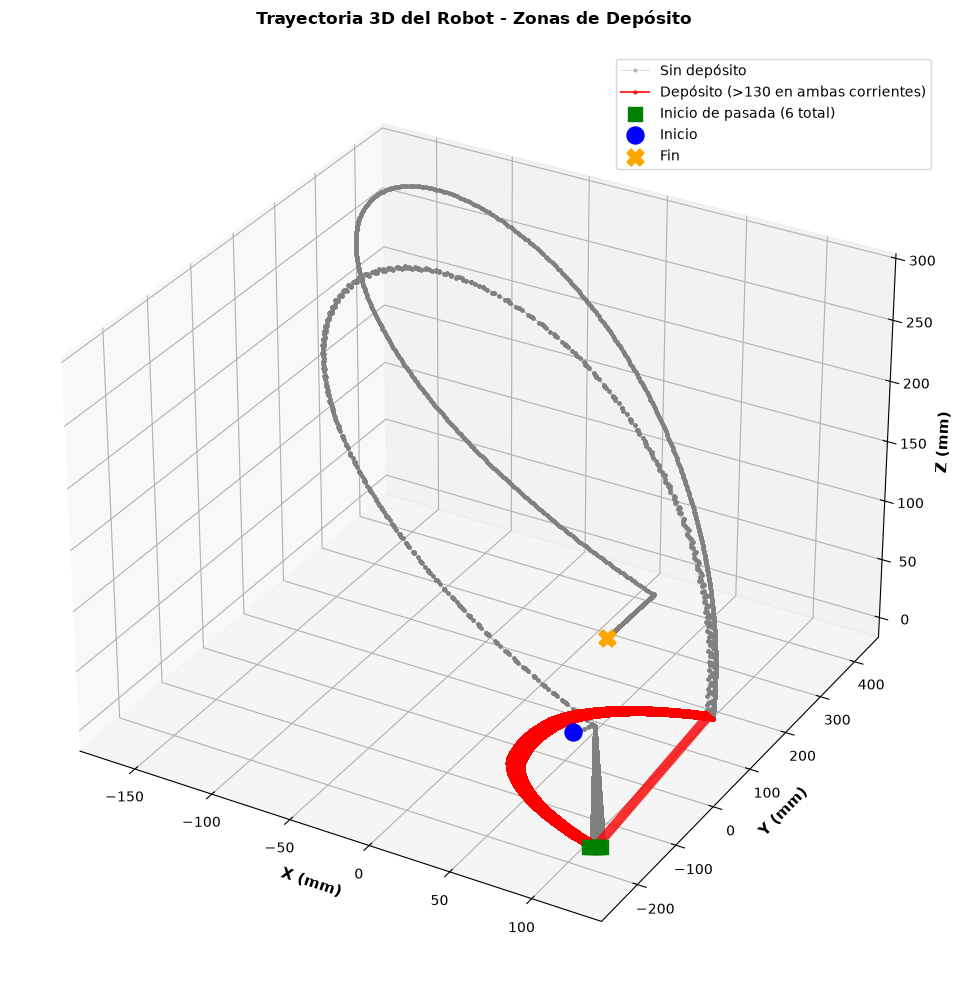


✓ Figura guardada: 01_trayectoria_3d.png


In [ ]:
# GRAFICAR TRAYECTORIA 3D
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# Registros sin condición de depósito
sin_deposito = ~depositando
ax.plot(
    x[sin_deposito], y[sin_deposito], z[sin_deposito],
    'o-',
    color='gray',
    alpha=0.4,
    markersize=2,
    linewidth=0.5,
    label='Sin depósito'
)

# Registros que cumplen la condición de depósito:
# ambas corrientes del LDM4000 > 130
con_deposito = depositando
ax.plot(
    x[con_deposito], y[con_deposito], z[con_deposito],
    'o-',
    color='red',
    alpha=0.8,
    markersize=2,
    linewidth=1.5,
    label='Depósito (>130 en ambas corrientes)'
)

# Marcar el inicio de cada pasada
if len(inicios_pasada) > 0:
    ax.scatter(
        x[inicios_pasada],
        y[inicios_pasada],
        z[inicios_pasada],
        color='green',
        s=100,
        marker='s',
        label=f'Inicio de pasada ({num_pasadas} total)',
        zorder=5
    )

# Punto inicial de la trayectoria
ax.scatter(
    x[0], y[0], z[0],
    color='blue',
    s=150,
    marker='o',
    label='Inicio',
    zorder=5
)

# Punto final de la trayectoria
ax.scatter(
    x[-1], y[-1], z[-1],
    color='orange',
    s=150,
    marker='X',
    label='Fin',
    zorder=5
)

# Etiquetas y formato
ax.set_xlabel('X (mm)', fontsize=11, fontweight='bold')
ax.set_ylabel('Y (mm)', fontsize=11, fontweight='bold')
ax.set_zlabel('Z (mm)', fontsize=11, fontweight='bold')

ax.set_title(
    'Trayectoria 3D del Robot - Zonas de Depósito',
    fontsize=12,
    fontweight='bold',
    pad=20
)

ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    output_dir / '01_trayectoria_3d.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print("\n✓ Figura guardada: 01_trayectoria_3d.png")

In [71]:
# Verificar cuántos puntos cumplen la condición de depósito
print("Total de registros:", len(df))
print("Puntos de depósito:", depositando.sum())
print("Porcentaje:", f"{depositando.mean() * 100:.2f}%")

Total de registros: 58708
Puntos de depósito: 27677
Porcentaje: 47.14%


**Conclusión:** el **47,14% de los registros (27 677 de 58 708)** cumple la condición de depósito, definida por corrientes superiores a 130 en ambos canales del LDM4000. Estos puntos corresponden a las zonas donde se produce el aporte de material sobre el arco; los tramos restantes representan desplazamientos u operaciones sin aporte según este criterio.

---

## ACTIVIDAD 3: Encontrar la Velocidad de Muestreo

### ANÁLISIS DE VELOCIDAD DE MUESTREO

El ejercicio propuesto solicita determinar qué tan rápido se generan las imágenes y qué tan regularmente se registran los datos del CSV, para posterior comprobar si existen interrupciones (huecos) o pérdidas de registros.

In [77]:
# Extraer timestamps de los archivos TIFF
timestamps_frames = np.array([f['timestamp'] for f in frames])

print(f"\n--- Frecuencia de Cámara (Frames TIFF) ---")
print(f"Número de frames: {len(frames)}")
print(f"Tiempo inicial (frame): {timestamps_frames[0]:.6f}")
print(f"Tiempo final (frame): {timestamps_frames[-1]:.6f}")
print(f"Duración total: {timestamps_frames[-1] - timestamps_frames[0]:.6f} segundos")



--- Frecuencia de Cámara (Frames TIFF) ---
Número de frames: 41645
Tiempo inicial (frame): 1764596703.019000
Tiempo final (frame): 1764597011.777000
Duración total: 308.758000 segundos


In [81]:
if len(frames) > 1:
    # Encontrar Δt: tiempo transcurrido entre dos frames consecutivos.
    delta_t_frames = np.diff(timestamps_frames)

    # Estadísticos del intervalo entre capturas
    media_dt = delta_t_frames.mean()
    mediana_dt = np.median(delta_t_frames)
    std_dt = delta_t_frames.std()

    print("\n--- INTERVALO DE MUESTREO DE LA CÁMARA ---")
    print(f"Δt mínimo:       {delta_t_frames.min()*1000:.3f} ms")
    print(f"Δt máximo:       {delta_t_frames.max()*1000:.3f} ms")
    print(f"Δt medio:        {media_dt*1000:.3f} ms")
    print(f"Δt mediano:      {mediana_dt*1000:.3f} ms")
    print(f"Desv. estándar:  {std_dt*1000:.3f} ms")

    # La frecuencia indica cuántos frames se adquieren por segundo.
    # Se calcula tanto con la media como con la mediana para comparar
    # el comportamiento global con el comportamiento típico.
    fps_media = 1 / media_dt
    fps_mediana = 1 / mediana_dt

    print(f"\nFPS usando Δt medio:    {fps_media:.2f} FPS")
    print(f"FPS usando Δt mediano:  {fps_mediana:.2f} FPS")

    # El período representa el tiempo esperado entre frames.
    print(f"Período medio:           {media_dt*1000:.3f} ms")

    # DETECCIÓN DE POSIBLES HUECOS
    # Se utiliza la mediana como referencia del intervalo habitual,
    # ya que es menos sensible a valores extremos.
    #
    # Un intervalo superior a 2 veces la mediana se considera
    # potencialmente anómalo y se revisa como posible hueco.
    umbral_hueco = 2 * mediana_dt

    huecos = np.where(delta_t_frames > umbral_hueco)[0]

    print("\n--- DETECCIÓN DE POSIBLES HUECOS ---")
    print(f"Umbral utilizado: {umbral_hueco*1000:.3f} ms")
    print(f"Posibles huecos:  {len(huecos)}")

    if len(huecos) > 0:

        print("\nPrimeros intervalos anómalos:")

        for idx in huecos[:5]:

            print(
                f"  Frame {idx} → {idx + 1}: "
                f"{delta_t_frames[idx]*1000:.3f} ms"
            )

    # REGULARIDAD DE LA ADQUISICIÓN
    # Porcentaje de intervalos que se mantienen dentro de ±20 %
    # respecto al intervalo mediano.
    tolerancia = 0.20 * mediana_dt

    intervalos_regulares = np.abs(
        delta_t_frames - mediana_dt
    ) <= tolerancia

    porcentaje_regular = (
        intervalos_regulares.mean() * 100
    )

    print("\n--- REGULARIDAD DE LA ADQUISICIÓN ---")
    print(
        f"Intervalos dentro de ±20 % de la mediana: "
        f"{porcentaje_regular:.2f}%"
    )


--- INTERVALO DE MUESTREO DE LA CÁMARA ---
Δt mínimo:       4.000 ms
Δt máximo:       13.000 ms
Δt medio:        7.414 ms
Δt mediano:      7.000 ms
Desv. estándar:  2.020 ms

FPS usando Δt medio:    134.88 FPS
FPS usando Δt mediano:  142.86 FPS
Período medio:           7.414 ms

--- DETECCIÓN DE POSIBLES HUECOS ---
Umbral utilizado: 14.000 ms
Posibles huecos:  0

--- REGULARIDAD DE LA ADQUISICIÓN ---
Intervalos dentro de ±20 % de la mediana: 38.43%


**Conclusión**: La cámara presenta una frecuencia media de adquisición de aproximadamente 134,9 FPS, con un intervalo típico de 7 ms entre frames. Los intervalos observados varían entre 4 y 13 ms, evidenciando variabilidad temporal en la adquisición. Sin embargo, no se detectan huecos significativos bajo el criterio de 2× la mediana, ya que ningún intervalo supera los 14 ms. 

**Importante**: Se evidencia que solo el **38,43 %** de los intervalos se encuentra dentro de ±20 % del intervalo mediano, por lo que la adquisición presenta variabilidad, aunque sin interrupciones temporales grandes.

### ANÁLISIS DE VELOCIDAD DE MUESTREO - CSV

In [82]:
timestamps_csv = df['timestamp*'].to_numpy()

# Verificar que los timestamps estén ordenados y no existan
# registros duplicados temporalmente.
delta_t_csv = np.diff(timestamps_csv)

registros_no_validos = np.sum(delta_t_csv <= 0)

print("\n--- FRECUENCIA DEL CSV (TELEMETRÍA DEL ROBOT) ---")

print(f"Número de registros: {len(df)}")
print(f"Tiempo inicial: {timestamps_csv[0]:.6f}")
print(f"Tiempo final:   {timestamps_csv[-1]:.6f}")
print(f"Duración total: {timestamps_csv[-1] - timestamps_csv[0]:.6f} s")


--- FRECUENCIA DEL CSV (TELEMETRÍA DEL ROBOT) ---
Número de registros: 58708
Tiempo inicial: 1764596703.019560
Tiempo final:   1764597011.782460
Duración total: 308.762900 s


In [86]:
print(f"\nRegistros con Δt <= 0: {registros_no_validos}")

# Si Δt <= 0 existe, hay timestamps repetidos o fuera de orden
# y la frecuencia calculada directamente podría no representar
# correctamente la secuencia temporal.
if registros_no_validos == 0:

    # Encontrar Δt: tiempo transcurrido entre dos registros
    delta_t_csv = np.diff(timestamps_csv)

    # Estadísticos del intervalo entre capturas
    media_dt_csv = delta_t_csv.mean()
    mediana_dt_csv = np.median(delta_t_csv)
    std_dt_csv = delta_t_csv.std()

    print("\nIntervalo Δt entre registros:")
    print(f"  Mínimo:     {delta_t_csv.min():.6f} s " f"({delta_t_csv.min()*1000:.3f} ms)")
    print(f"  Máximo:     {delta_t_csv.max():.6f} s " f"({delta_t_csv.max()*1000:.3f} ms)")
    print(f"  Media:      {media_dt_csv:.6f} s "f"({media_dt_csv*1000:.3f} ms)")
    print(f"  Mediana:    {mediana_dt_csv:.6f} s " f"({mediana_dt_csv*1000:.3f} ms)")
    print(f"  Desv. estándar: {std_dt_csv:.6f} s "f"({std_dt_csv*1000:.3f} ms)")

    # La frecuencia indica cuántos registros de telemetría
    # se generan aproximadamente por segundo.
    fps_csv = 1.0 / media_dt_csv

    # La mediana representa mejor el intervalo temporal típico
    # cuando existen intervalos ocasionalmente más largos o cortos.
    frecuencia_tipica_csv = 1.0 / mediana_dt_csv

    print("\nFrecuencia de muestreo:")

    print(f"  Frecuencia media:   {fps_csv:.2f} Hz")
    print(f"  Frecuencia típica:  {frecuencia_tipica_csv:.2f} Hz")

    print(f"  Período medio:      {media_dt_csv*1000:.3f} ms")

    #  DETECCIÓN DE POSIBLES HUECOS
    # Se utiliza el doble del intervalo mediano como referencia.
    # Un intervalo superior a este valor representa una separación
    # temporal considerable respecto al ritmo habitual de muestreo.
    umbral_hueco_csv = 2 * mediana_dt_csv

    huecos_csv = np.where(delta_t_csv > umbral_hueco_csv)[0]

    print("\n--- DETECCIÓN DE POSIBLES HUECOS ---")
    print(
        f"Umbral utilizado: "
        f"{umbral_hueco_csv*1000:.3f} ms"
    )
    print(f"Posibles huecos: {len(huecos_csv)}")

    if len(huecos_csv) > 0:
        print(f"Primeros 5 índices: {huecos_csv[:5]}")

        # Mostrar cuánto duraron los primeros intervalos anómalos.
        print(
            "Primeros Δt anómalos:",
            delta_t_csv[huecos_csv[:5]] * 1000,
            "ms"
        )

    #  REGULARIDAD DEL MUESTREO
    # Se considera "cercano" al intervalo típico aquel que se
    # encuentra dentro de ±20 % de la mediana.
    tolerancia_csv = 0.20 * mediana_dt_csv

    intervalos_regulares_csv = (
        np.abs(delta_t_csv - mediana_dt_csv)
        <= tolerancia_csv
    )

    porcentaje_regular_csv = (
        intervalos_regulares_csv.mean() * 100
    )

    print("\n--- REGULARIDAD DEL MUESTREO ---")
    print(
        f"Intervalos dentro de ±20 % de la mediana: "
        f"{porcentaje_regular_csv:.5f}%"
    )


Registros con Δt <= 0: 0

Intervalo Δt entre registros:
  Mínimo:     0.005100 s (5.100 ms)
  Máximo:     0.006420 s (6.420 ms)
  Media:      0.005259 s (5.259 ms)
  Mediana:    0.005250 s (5.250 ms)
  Desv. estándar: 0.000064 s (0.064 ms)

Frecuencia de muestreo:
  Frecuencia media:   190.14 Hz
  Frecuencia típica:  190.48 Hz
  Período medio:      5.259 ms

--- DETECCIÓN DE POSIBLES HUECOS ---
Umbral utilizado: 10.500 ms
Posibles huecos: 0

--- REGULARIDAD DEL MUESTREO ---
Intervalos dentro de ±20 % de la mediana: 99.99830%


In [87]:
indices_fuera = np.where(~intervalos_regulares_csv)[0]

print(f"\nCantidad fuera del rango: {len(indices_fuera)}")

if len(indices_fuera) > 0:
    print("Primeros intervalos fuera del rango:")
    print(delta_t_csv[indices_fuera[:10]] * 1000)


Cantidad fuera del rango: 1
Primeros intervalos fuera del rango:
[6.41989708]


**Conclusión**: El CSV presenta una frecuencia de muestreo de 190,14 Hz, con un intervalo medio de 5,259 ms y una desviación estándar de apenas 0,064 ms, lo que evidencia un muestreo temporal altamente regular. De los 58.707 intervalos analizados, 58.706 (99,998 %) se encuentran dentro de ±20 % de la mediana (5,250 ms) y solo 1 intervalo, de 6,420 ms, se encuentra fuera de este rango. Este intervalo aislado no constituye un hueco significativo, ya que permanece por debajo del umbral de 10,500 ms (2× la mediana).

### HISTOGRAMA DE INTERVALOS DE TIEMPO 

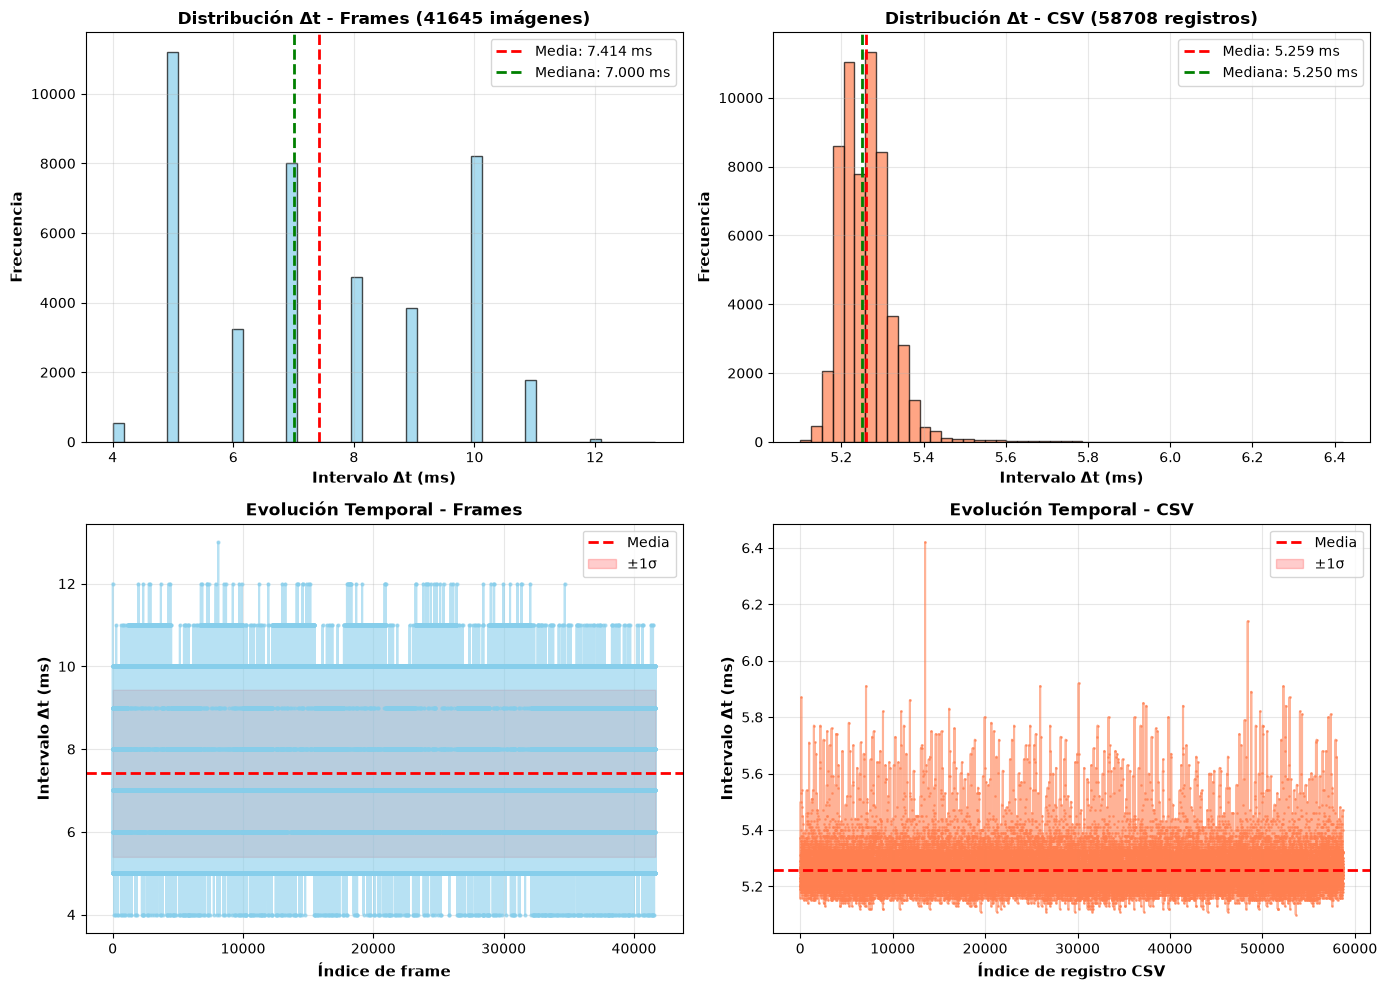


✓ Figura guardada: 02_distribucion_intervalos_tiempo.png


In [88]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histograma de Δt de frames
if len(frames) > 1:
    ax = axes[0, 0]
    ax.hist(delta_t_frames * 1000, bins=50, color='skyblue', alpha=0.7, edgecolor='black')
    ax.axvline(delta_t_frames.mean() * 1000, color='red', linestyle='--', linewidth=2, 
               label=f'Media: {delta_t_frames.mean()*1000:.3f} ms')
    ax.axvline(np.median(delta_t_frames) * 1000, color='green', linestyle='--', linewidth=2,
               label=f'Mediana: {np.median(delta_t_frames)*1000:.3f} ms')
    ax.set_xlabel('Intervalo Δt (ms)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Frecuencia', fontsize=11, fontweight='bold')
    ax.set_title(f'Distribución Δt - Frames ({len(frames)} imágenes)', fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
else:
    axes[0, 0].text(0.5, 0.5, 'Solo 1 frame disponible', ha='center', va='center')

# Histograma de Δt del CSV
ax = axes[0, 1]
ax.hist(delta_t_csv * 1000, bins=50, color='coral', alpha=0.7, edgecolor='black')
ax.axvline(delta_t_csv.mean() * 1000, color='red', linestyle='--', linewidth=2, 
           label=f'Media: {delta_t_csv.mean()*1000:.3f} ms')
ax.axvline(np.median(delta_t_csv) * 1000, color='green', linestyle='--', linewidth=2,
           label=f'Mediana: {np.median(delta_t_csv)*1000:.3f} ms')
ax.set_xlabel('Intervalo Δt (ms)', fontsize=11, fontweight='bold')
ax.set_ylabel('Frecuencia', fontsize=11, fontweight='bold')
ax.set_title(f'Distribución Δt - CSV ({len(df)} registros)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Evolución temporal de Δt - Frames
if len(frames) > 1:
    ax = axes[1, 0]
    ax.plot(delta_t_frames * 1000, 'o-', markersize=2, alpha=0.6, color='skyblue')
    ax.axhline(delta_t_frames.mean() * 1000, color='red', linestyle='--', linewidth=2, label='Media')
    ax.fill_between(range(len(delta_t_frames)), 
                     (delta_t_frames.mean() - delta_t_frames.std()) * 1000,
                     (delta_t_frames.mean() + delta_t_frames.std()) * 1000,
                     alpha=0.2, color='red', label='±1σ')
    ax.set_xlabel('Índice de frame', fontsize=11, fontweight='bold')
    ax.set_ylabel('Intervalo Δt (ms)', fontsize=11, fontweight='bold')
    ax.set_title('Evolución Temporal - Frames', fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
else:
    axes[1, 0].text(0.5, 0.5, 'Solo 1 frame disponible', ha='center', va='center')

# Evolución temporal de Δt - CSV
ax = axes[1, 1]
ax.plot(delta_t_csv * 1000, 'o-', markersize=1, alpha=0.6, color='coral')
ax.axhline(delta_t_csv.mean() * 1000, color='red', linestyle='--', linewidth=2, label='Media')
ax.fill_between(range(len(delta_t_csv)), 
                 (delta_t_csv.mean() - delta_t_csv.std()) * 1000,
                 (delta_t_csv.mean() + delta_t_csv.std()) * 1000,
                 alpha=0.2, color='red', label='±1σ')
ax.set_xlabel('Índice de registro CSV', fontsize=11, fontweight='bold')
ax.set_ylabel('Intervalo Δt (ms)', fontsize=11, fontweight='bold')
ax.set_title('Evolución Temporal - CSV', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(output_dir / '02_distribucion_intervalos_tiempo.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Figura guardada: 02_distribucion_intervalos_tiempo.png")

**Nota**: La cámara presenta una mayor variabilidad en sus intervalos de adquisición, mientras que la telemetría del CSV presenta un muestreo mucho más uniforme. La comparación de ambas distribuciones permite caracterizar no solo sus frecuencias medias, sino también la estabilidad temporal de cada sistema.

---

## ACTIVIDAD 4: Diferencias de Timestamps

### SINCRONIZACIÓN FRAME - CSV

La idea central, es para cada frame, encontrar el registro de telemetría temporalmente más cercano.

Como los timestamps están ordenados, utilizamos **np.searchsorted()** en lugar de comparar cada frame contra TODOS los registros del CSV.

In [95]:
# PREPARAR TIMESTAMPS
timestamps_frames = np.array([frame['timestamp'] for frame in frames if frame['timestamp'] is not None])
timestamps_csv = df['timestamp*'].to_numpy()

# BUSCAR LOS DOS REGISTROS CSV QUE RODEAN TEMPORALMENTE A CADA FRAME
indices_derecha = np.searchsorted(timestamps_csv, timestamps_frames, side='left')
indices_posteriores = np.clip(indices_derecha, 0, len(timestamps_csv) - 1)
indices_anteriores = np.clip(indices_derecha - 1, 0, len(timestamps_csv) - 1)

# CALCULAR LA DISTANCIA A LOS CANDIDATOS Y SELECCIONAR EL MÁS CERCANO
distancia_anterior = np.abs(timestamps_frames - timestamps_csv[indices_anteriores])
distancia_posterior = np.abs(timestamps_frames - timestamps_csv[indices_posteriores])
indices_csv_asociados = np.where(distancia_anterior <= distancia_posterior, indices_anteriores, indices_posteriores)

# CALCULAR DESFASE CON SIGNO Y ERROR ABSOLUTO
timestamps_csv_asociados = timestamps_csv[indices_csv_asociados]
diferencias_timestamps = timestamps_frames - timestamps_csv_asociados
errores_absolutos = np.abs(diferencias_timestamps)

# ESTADÍSTICAS DE SINCRONIZACIÓN
print("\n--- ERROR DE SINCRONIZACIÓN ---")
print(f"Frames sincronizados: {len(timestamps_frames)}")
print(f"Error medio: {errores_absolutos.mean()*1000:.3f} ms")
print(f"Error mediano: {np.median(errores_absolutos)*1000:.3f} ms")
print(f"Desv. estándar: {errores_absolutos.std()*1000:.3f} ms")
print(f"Error mínimo: {errores_absolutos.min()*1000:.3f} ms")
print(f"Error máximo: {errores_absolutos.max()*1000:.3f} ms")
print(f"Percentil 95: {np.percentile(errores_absolutos, 95)*1000:.3f} ms")


--- ERROR DE SINCRONIZACIÓN ---
Frames sincronizados: 41645
Error medio: 1.321 ms
Error mediano: 1.320 ms
Desv. estándar: 0.760 ms
Error mínimo: 0.000 ms
Error máximo: 2.870 ms
Percentil 95: 2.500 ms


**Importante**: La sincronización temporal entre los 41.645 frames TIFF y la telemetría se realizó de forma consistente. El error medio de asociación fue de 1,321 ms, con una mediana de 1,320 ms y una desviación estándar de 0,760 ms. El 95 % de los frames presentó un error igual o inferior a 2,500 ms, mientras que el error máximo fue de 2,870 ms. Estos resultados indican que cada imagen puede asociarse con buena precisión temporal al registro de telemetría más cercano, permitiendo utilizar conjuntamente la información visual y las variables del proceso para análisis posteriores.

**Justificación de la tolerancia:** Se establece una tolerancia de ±7,889 ms, equivalente a 1,5 veces el período medio de muestreo de la telemetría (5,259 ms). Este criterio proporciona un margen razonable para asociar cada frame con el registro CSV temporalmente más cercano, considerando que ambas fuentes tienen frecuencias de adquisición diferentes; se trata de un criterio definido para este análisis y no de un estándar universal.

In [ ]:
# RELACIÓN TEMPORAL FRAME - CSV
# El desfase con signo permite determinar si el frame ocurrió antes o después del registro CSV asociado.
frames_despues_csv = np.sum(diferencias_timestamps > 0)
frames_antes_csv = np.sum(diferencias_timestamps < 0)
frames_mismo_timestamp = np.sum(diferencias_timestamps == 0)
print("\n--- RELACIÓN TEMPORAL ---")
print(f"Frames después del CSV: {frames_despues_csv}")
print(f"Frames antes del CSV: {frames_antes_csv}")
print(f"Frames con timestamp idéntico: {frames_mismo_timestamp}")

# TOLERANCIA DE SINCRONIZACIÓN
# Se utiliza 1,5 veces el período medio del CSV como criterio de aceptación
periodo_medio_csv = delta_t_csv.mean()
tolerancia_maxima = 1.5 * periodo_medio_csv
print("\n--- TOLERANCIA PROPUESTA ---")
print(f"Período medio CSV: {periodo_medio_csv * 1000:.3f} ms")
print(f"Tolerancia máxima: {tolerancia_maxima * 1000:.3f} ms")

# EVALUAR LA SINCRONIZACIÓN
# Un frame cumple el criterio cuando el registro CSV más cercano está dentro de la tolerancia temporal definida.
frames_dentro_tolerancia = errores_absolutos <= tolerancia_maxima
cantidad_dentro = frames_dentro_tolerancia.sum()
cantidad_fuera = (~frames_dentro_tolerancia).sum()
porcentaje_dentro = cantidad_dentro / len(errores_absolutos) * 100
porcentaje_fuera = cantidad_fuera / len(errores_absolutos) * 100
print("\n--- RESULTADO DE SINCRONIZACIÓN ---")
print(f"Frames dentro de tolerancia: {cantidad_dentro}/{len(errores_absolutos)} ({porcentaje_dentro:.2f}%)")
print(f"Frames fuera de tolerancia: {cantidad_fuera}/{len(errores_absolutos)} ({porcentaje_fuera:.2f}%)")

# IDENTIFICAR CASOS FUERA DE TOLERANCIA
# Se identifican los frames que superan el criterio establecido para revisar posibles casos atípicos.
indices_fuera = np.where(~frames_dentro_tolerancia)[0]
if len(indices_fuera) > 0:
    print("\n--- FRAMES FUERA DE TOLERANCIA ---")
    for idx in indices_fuera[:10]:
        print(f"Frame {idx} | Error: {errores_absolutos[idx] * 1000:.3f} ms | CSV asociado: {indices_csv_asociados[idx]}")
else:
    print("\nTodos los frames están dentro de la tolerancia propuesta.")

#  GUARDAR LA ASOCIACIÓN FRAME → CSV
# Se conserva el índice del frame, el registro CSV asociado, el desfase con signo y el error absoluto para análisis posteriores.
asociacion_frames = np.column_stack([np.arange(len(timestamps_frames)), indices_csv_asociados, diferencias_timestamps, errores_absolutos])


--- RELACIÓN TEMPORAL ---
Frames después del CSV: 20791
Frames antes del CSV: 20786
Frames con timestamp idéntico: 68

--- TOLERANCIA PROPUESTA ---
Período medio CSV: 5.259 ms
Tolerancia máxima: 7.889 ms

--- RESULTADO DE SINCRONIZACIÓN ---
Frames dentro de tolerancia: 41645/41645 (100.00%)
Frames fuera de tolerancia: 0/41645 (0.00%)

Todos los frames están dentro de la tolerancia propuesta.


**Conclusión**: Los 41.645 frames (100 %) se encuentran dentro de la tolerancia y ninguno supera los 7,889 ms establecidos. Además, 20.791 frames ocurrieron después del registro CSV asociado, 20.786 antes y 68 coincidieron exactamente, mostrando una distribución prácticamente equilibrada del desfase temporal. Por tanto, la asociación frame–telemetría es consistente y adecuada para integrar posteriormente las variables del proceso a cada imagen.

### HISTOGRAMA DE DIFERENCIAS DE TIMESTAMP

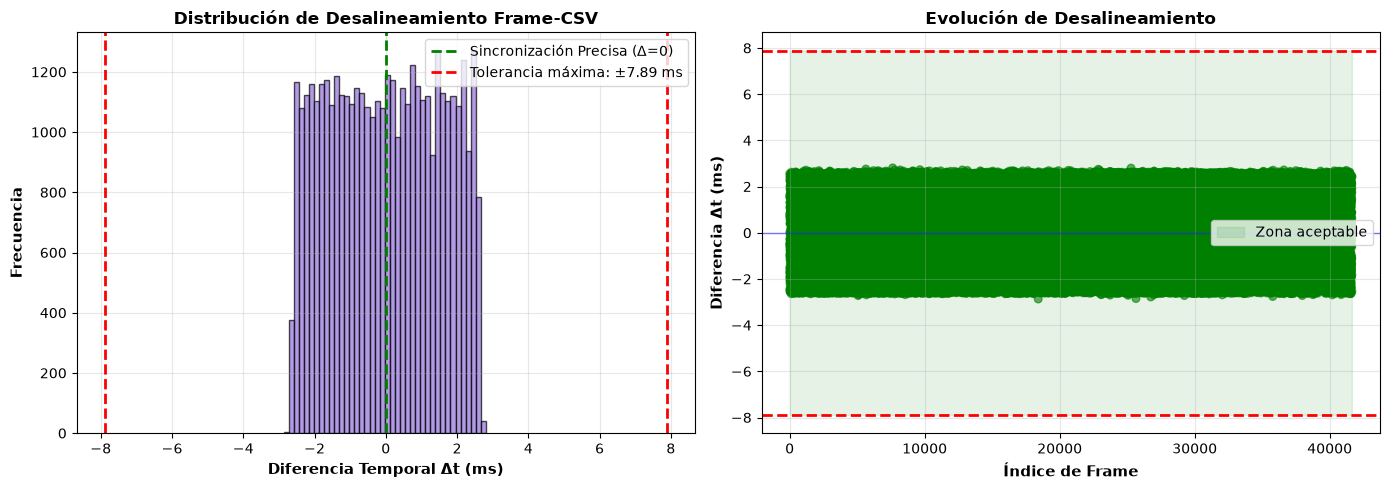

✓ Figura guardada: 03_diferencias_timestamps.png


In [100]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de diferencias
ax = axes[0]
ax.hist(diferencias_timestamps * 1000, bins=40, color='mediumpurple', alpha=0.7, edgecolor='black')
ax.axvline(0, color='green', linestyle='--', linewidth=2, label='Sincronización Precisa (Δ=0)')
ax.axvline(tolerancia_maxima * 1000, color='red', linestyle='--', linewidth=2, 
           label=f'Tolerancia máxima: ±{tolerancia_maxima*1000:.2f} ms')
ax.axvline(-tolerancia_maxima * 1000, color='red', linestyle='--', linewidth=2)
ax.set_xlabel('Diferencia Temporal Δt (ms)', fontsize=11, fontweight='bold')
ax.set_ylabel('Frecuencia', fontsize=11, fontweight='bold')
ax.set_title('Distribución de Desalineamiento Frame-CSV', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Gráfico de dispersión
ax = axes[1]
indices = np.arange(len(diferencias_timestamps))
colores = np.where(np.abs(diferencias_timestamps) <= tolerancia_maxima, 'green', 'red')
ax.scatter(indices, diferencias_timestamps * 1000, c=colores, alpha=0.6, s=30)
ax.axhline(0, color='blue', linestyle='-', linewidth=1, alpha=0.5)
ax.axhline(tolerancia_maxima * 1000, color='red', linestyle='--', linewidth=2)
ax.axhline(-tolerancia_maxima * 1000, color='red', linestyle='--', linewidth=2)
ax.fill_between(indices, -tolerancia_maxima * 1000, tolerancia_maxima * 1000,
                 alpha=0.1, color='green', label='Zona aceptable')
ax.set_xlabel('Índice de Frame', fontsize=11, fontweight='bold')
ax.set_ylabel('Diferencia Δt (ms)', fontsize=11, fontweight='bold')
ax.set_title('Evolución de Desalineamiento', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(output_dir / '03_diferencias_timestamps.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Figura guardada: 03_diferencias_timestamps.png")

**Nota**: La sincronización temporal aplicada es consistente y se encuentra dentro de los límites de tolerancia. Las pequeñas fluctuaciones observadas son normales y no afectan la correspondencia entre los frames y los registros del CSV.

---

## ACTIVIDAD 5: Generar CSV Mejorado

### ANÁLISIS DE COLUMNAS CONSTANTES

In [102]:
print("\n=== ANÁLISIS DE VALIDEZ DE DATOS ===")
print("Identificando columnas constantes o con poca variación...\n")

columnas_constantes = []
columnas_sospechosas = {}

for col in df.columns:
    # El timestamp se excluye porque representa el eje temporal del proceso.
    if col == 'timestamp*':
        continue

    # Una columna con un solo valor no aporta variabilidad al análisis.
    if df[col].nunique() == 1:
        columnas_constantes.append(col)
        print(f"CONSTANTE: {col} = {df[col].iloc[0]}")

    # La moda permite detectar variables donde un mismo valor domina casi todos los registros.
    moda = df[col].mode()
    if not moda.empty:
        porcentaje_moda = (df[col] == moda.iloc[0]).mean() * 100

        # Más del 95 % repetido se marca como poco variante para revisión.
        if porcentaje_moda > 95:
            columnas_sospechosas[col] = (moda.iloc[0], porcentaje_moda)
            print(f"POCO VARIANTE: {col} - {porcentaje_moda:.1f}% = {moda.iloc[0]}")

print(f"\nColumnas constantes: {len(columnas_constantes)}")
print(f"Columnas poco variantes (>95%): {len(columnas_sospechosas)}")


=== ANÁLISIS DE VALIDEZ DE DATOS ===
Identificando columnas constantes o con poca variación...

CONSTANTE: ExposureTime_i = 60
POCO VARIANTE: ExposureTime_i - 100.0% = 60
CONSTANTE: BlackLevel_i = 1
POCO VARIANTE: BlackLevel_i - 100.0% = 1
CONSTANTE: Laser_On_i = 1
POCO VARIANTE: Laser_On_i - 100.0% = 1
CONSTANTE: EAXA = 8999999488
POCO VARIANTE: EAXA - 100.0% = 8999999488
CONSTANTE: EAXD = 8999999488
POCO VARIANTE: EAXD - 100.0% = 8999999488
CONSTANTE: EAXE = 8999999488
POCO VARIANTE: EAXE - 100.0% = 8999999488
CONSTANTE: EAXF = 8999999488
POCO VARIANTE: EAXF - 100.0% = 8999999488

Columnas constantes: 7
Columnas poco variantes (>95%): 7


**Conclusión**: el conjunto presenta variables de configuración y señales sin variación que deben considerarse antes del modelado, ya que no contienen información discriminante en el tiempo. Las variables dinámicas restantes son las que permiten analizar la evolución del proceso.

### CREAR NUEVO CSV MEJORADO CON INFORMACIÓN DE FRAMES

In [104]:
# Copiar el dataframe y crear columnas para asociar cada registro con su frame más cercano.
df_mejorado = df.copy()

df_mejorado['nombre_frame_asociado'] = None
df_mejorado['timestamp_frame'] = None
df_mejorado['diferencia_timestamp_frame_ms'] = None
df_mejorado['intensidad_maxima_frame'] = None
df_mejorado['intensidad_media_frame'] = None

# Asociar cada registro CSV con el frame temporalmente más cercano.
for i, frame in enumerate(frames):
    idx_csv = indices_csv_asociados[i]
    df_mejorado.loc[idx_csv, 'nombre_frame_asociado'] = frame['archivo']
    df_mejorado.loc[idx_csv, 'timestamp_frame'] = frame['timestamp']
    df_mejorado.loc[idx_csv, 'diferencia_timestamp_frame_ms'] = diferencias_timestamps[i] * 1000
    df_mejorado.loc[idx_csv, 'intensidad_maxima_frame'] = frame['max']
    df_mejorado.loc[idx_csv, 'intensidad_media_frame'] = frame['media']

# Tiempo relativo desde el inicio del proceso.
df_mejorado['tiempo_relativo'] = df['timestamp*'] - df['timestamp*'].iloc[0]

# Estado de depósito: ambas corrientes del láser deben superar 130.
df_mejorado['depositando'] = (
    (df['LDM4000_Current_Monitor_1'] > 130) &
    (df['LDM4000_Current_Monitor_2'] > 130)
)

# Detectar el inicio de cada pasada cuando se pasa de NO depósito a depósito.
cambios_deposito = np.diff(
    df_mejorado['depositando'].astype(int),
    prepend=0
)

df_mejorado['numero_pasada'] = np.where(
    df_mejorado['depositando'],
    np.cumsum(cambios_deposito > 0),
    0
)

# Reordenar columnas principales para facilitar el análisis.
columnas_nuevas = [
    'timestamp*',
    'nombre_frame_asociado',
    'timestamp_frame',
    'diferencia_timestamp_frame_ms',
    'tiempo_relativo',
    'depositando',
    'numero_pasada',
    'x', 'y', 'z',
    'intensidad_maxima_frame',
    'intensidad_media_frame',
    'ExposureTime_i',
    'BlackLevel_i',
    'PyrometerTemperature',
    'ProcessTemperature'
]

columnas_finales = [c for c in columnas_nuevas if c in df_mejorado.columns]
columnas_finales += [c for c in df_mejorado.columns if c not in columnas_finales]
df_mejorado = df_mejorado[columnas_finales]

print(f"\n--- CSV MEJORADO GENERADO ---")
print(f"Dimensiones: {df_mejorado.shape}")
print(f"Pasadas detectadas: {df_mejorado['numero_pasada'].max()}")
print(f"Registros en depósito: {df_mejorado['depositando'].sum():,}")
print(f"Registros sin depósito: {(~df_mejorado['depositando']).sum():,}")

print("\nPrimeras 10 filas:")
print(df_mejorado[
    ['timestamp*', 'nombre_frame_asociado', 'tiempo_relativo',
     'depositando', 'numero_pasada', 'intensidad_maxima_frame']
].head(10))


--- CSV MEJORADO GENERADO ---
Dimensiones: (58708, 29)
Pasadas detectadas: 6
Registros en depósito: 27,677
Registros sin depósito: 31,031

Primeras 10 filas:
     timestamp* nombre_frame_asociado  tiempo_relativo  depositando  \
0  1.764597e+09    1764596703019.tiff          0.00000        False   
1  1.764597e+09                  None          0.00537        False   
2  1.764597e+09    1764596703031.tiff          0.01065        False   
3  1.764597e+09    1764596703037.tiff          0.01589        False   
4  1.764597e+09                  None          0.02115        False   
5  1.764597e+09    1764596703044.tiff          0.02638        False   
6  1.764597e+09                  None          0.03163        False   
7  1.764597e+09    1764596703059.tiff          0.03688        False   
8  1.764597e+09                  None          0.04217        False   
9  1.764597e+09    1764596703066.tiff          0.04740        False   

   numero_pasada intensidad_maxima_frame  
0              0

**Criterio de asociación**: cada frame TIFF se vinculó con el registro CSV temporalmente más cercano. Los registros CSV que no fueron seleccionados por ningún frame se conservaron con nombre_frame_asociado = None, sin eliminar información de la telemetría original.

### GUARDAR CSV MEJORADO

In [ ]:
# Crear csv con la información mejorada y asociada a los frames.
csv_salida = output_dir / 'datos_sincronizados_v2.csv'
df_mejorado.to_csv(csv_salida, index=False)

print(f"✓ CSV mejorado guardado: {csv_salida}")
print(f"  Tamaño: {csv_salida.stat().st_size / 1024:.1f} KB")

✓ CSV mejorado guardado: C:\Users\noeli\OneDrive\Documentos\CursoIA\Data\outputs\datos_sincronizados_v2.csv
  Tamaño: 16431.5 KB


### REGISTRO DE METADATA EN JSON

Se construye el JSON de parametría con el objetivo de documentación (conocimiento transferible) debido a que este permite saber cómo se generó el csv mejorado y bajo qué criterios fue construido: cuántos datos tenía, cuántas imágenes, cómo se sincronizaron, cuál fue el error, qué columnas eran constantes y cómo se definieron las pasadas.

In [108]:
# Registrar los parámetros y resultados utilizados para construir el CSV mejorado.
registro_procesamiento = {
    "descripcion": "Procesamiento y sincronización de datos de deposición",
    "fecha_procesamiento": datetime.now().isoformat(),
    "archivo_csv_original": str(csv_path),
    "numero_registros_csv": len(df_mejorado),
    "numero_frames_tiff": len(frames),

    "parametros_sincronizacion": {
        "tolerancia_maxima_ms": float(tolerancia_maxima * 1000),
        "fps_csv": float(fps_csv),
        "periodo_csv_ms": float(delta_t_csv.mean() * 1000),
        "fps_frames": float(fps_frames),
        "periodo_frames_ms": float(delta_t_frames.mean() * 1000)
    },

    "error_sincronizacion_ms": {
        "media": float(errores_absolutos.mean() * 1000),
        "mediana": float(np.median(errores_absolutos) * 1000),
        "std": float(errores_absolutos.std() * 1000),
        "min": float(errores_absolutos.min() * 1000),
        "max": float(errores_absolutos.max() * 1000),
        "p95": float(np.percentile(errores_absolutos, 95) * 1000)
    },

    "calidad_datos": {
        "columnas_constantes": columnas_constantes,
        "columnas_poco_variantes": {
            k: [v[0].item() if hasattr(v[0], "item") else v[0], float(v[1])]
            for k, v in columnas_sospechosas.items()
        }
    },

    "estadisticas_imagenes": {
        "numero_frames": len(frames),
        "dimensiones": f"{frames[0]['shape'][0]}x{frames[0]['shape'][1]}",
        "dtype": str(frames[0]['dtype']),
        "bits_efectivos": int(bits_efectivos),
        "porcentaje_pixels_cero": float(porcentaje_cero),
        "intensidad_minima": float(minimos.min()),
        "intensidad_maxima": float(maximos.max())
    },

    "proceso_deposito": {
        "numero_pasadas": int(df_mejorado['numero_pasada'].max()),
        "registros_deposito": int(df_mejorado['depositando'].sum()),
        "porcentaje_deposito": float(df_mejorado['depositando'].mean() * 100)
    },

    "trayectoria": {
        "x_rango": [float(x.min()), float(x.max())],
        "y_rango": [float(y.min()), float(y.max())],
        "z_rango": [float(z.min()), float(z.max())]
    },

    "versiones_librerias": {
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "matplotlib": plt.matplotlib.__version__
    }
}

registro_salida = output_dir / "registro_procesamiento.json"

with open(registro_salida, "w") as f:
    json.dump(registro_procesamiento, f, indent=2)

print(f"✓ Registro guardado: {registro_salida}")

✓ Registro guardado: C:\Users\noeli\OneDrive\Documentos\CursoIA\Data\outputs\registro_procesamiento.json


---

## ACTIVIDAD 6: Reducir el Tamaño de las Imágenes

### CÁLCULO DEL MÁXIMO ACUMULADO DE TODOS LOS FRAMES

El máximo acumulado es una herramienta para descubrir dónde estuvo la señal durante todo el proceso y, a partir de eso, definir un recorte que no elimine ninguna zona donde apareció señal.

In [109]:
if len(frames) > 0:
    # Inicializar máximo acumulado con ceros
    shape_imagen = frames[0]['shape']
    maximo_acumulado = np.zeros(shape_imagen, dtype=np.uint16)
    
    for i, archivo_path in enumerate(archivos_tiff):
        imagen = leer_imagen_tiff(archivo_path)
        maximo_acumulado = np.maximum(maximo_acumulado, imagen)
        del imagen
        
        if (i + 1) % max(1, len(archivos_tiff)//10) == 0 or i == len(archivos_tiff) - 1:
            print(f'  [{i+1}/{len(archivos_tiff)}] Máximo acumulado actualizado')
    
    print('\nMáximo acumulado calculado')
    print(f'Valor máximo global: {maximo_acumulado.max()}')

  [4164/41645] Máximo acumulado actualizado
  [8328/41645] Máximo acumulado actualizado
  [12492/41645] Máximo acumulado actualizado
  [16656/41645] Máximo acumulado actualizado
  [20820/41645] Máximo acumulado actualizado
  [24984/41645] Máximo acumulado actualizado
  [29148/41645] Máximo acumulado actualizado
  [33312/41645] Máximo acumulado actualizado
  [37476/41645] Máximo acumulado actualizado
  [41640/41645] Máximo acumulado actualizado
  [41645/41645] Máximo acumulado actualizado

Máximo acumulado calculado
Valor máximo global: 65520


### ANÁLISIS DE ÁREA ÚTIL

Se define un umbral estadístico correspondiente al percentil 5 de las intensidades no nulas del máximo acumulado.

In [110]:
# Encontrar píxeles con señal basándose en máximo acumulado
# Umbral: píxeles con valor > percentil 5 de los píxeles no-cero
pixels_no_cero = maximo_acumulado[maximo_acumulado > 0]
if len(pixels_no_cero) > 0:
    umbral_señal = np.percentile(pixels_no_cero, 5)
    mascara_señal = maximo_acumulado > umbral_señal
else:
    umbral_señal = 0
    mascara_señal = maximo_acumulado > umbral_señal

print(f"\n--- Caracterización de Máximo Acumulado ---")
print(f"Dimensiones: {maximo_acumulado.shape[0]} × {maximo_acumulado.shape[1]} píxeles")
print(f"Área total: {maximo_acumulado.size} píxeles")
print(f"Píxeles con señal (>{umbral_señal:.1f}): {mascara_señal.sum()}")
print(f"Porcentaje de área útil: {100 * mascara_señal.sum() / maximo_acumulado.size:.2f}%")
print(f"Porcentaje de fondo/desperdicio: {100 * (1 - mascara_señal.sum() / maximo_acumulado.size):.2f}%")


--- Caracterización de Máximo Acumulado ---
Dimensiones: 520 × 656 píxeles
Área total: 341120 píxeles
Píxeles con señal (>256.0): 61658
Porcentaje de área útil: 18.08%
Porcentaje de fondo/desperdicio: 81.92%


### ESTRATEGIA 1: RECORTE MANUAL

In [111]:
# Encontrar bounding box de píxeles con señal
filas_con_señal = np.where(mascara_señal.any(axis=1))[0]
cols_con_señal = np.where(mascara_señal.any(axis=0))[0]

if len(filas_con_señal) > 0 and len(cols_con_señal) > 0:
    y_min_auto, y_max_auto = filas_con_señal[0], filas_con_señal[-1]
    x_min_auto, x_max_auto = cols_con_señal[0], cols_con_señal[-1]
    
    # Usar valores automáticos como sugerencia pero aplicar margen
    margen = 10
    y_min = max(0, y_min_auto - margen)
    y_max = min(maximo_acumulado.shape[0] - 1, y_max_auto + margen)
    x_min = max(0, x_min_auto - margen)
    x_max = min(maximo_acumulado.shape[1] - 1, x_max_auto + margen)
    
    ancho_roi_manual = x_max - x_min
    alto_roi_manual = y_max - y_min
    
    # Recortar máximo acumulado para visualización
    maximo_recortado_manual = maximo_acumulado[y_min:y_max, x_min:x_max]
    
    print(f"Región de interés (x, y, ancho, alto): ({x_min}, {y_min}, {ancho_roi_manual}, {alto_roi_manual})")
    print(f"Imagen recortada: {maximo_recortado_manual.shape}")
    print(f"Reducción de área: {100 * (1 - maximo_recortado_manual.size / maximo_acumulado.size):.1f}%")
    
    # Verificar que no hemos perdido señal importante
    mascara_señal_recortada = maximo_recortado_manual > umbral_señal
    print(f"Píxeles con señal retenidos: {mascara_señal_recortada.sum()}")
    print(f"Porcentaje de señal retenida: {100*mascara_señal_recortada.sum()/mascara_señal.sum():.1f}%")
else:
    print("No hay píxeles con señal identificados.")
    maximo_recortado_manual = maximo_acumulado
    x_min, y_min, ancho_roi_manual, alto_roi_manual = 0, 0, maximo_acumulado.shape[1], maximo_acumulado.shape[0]

Región de interés (x, y, ancho, alto): (153, 34, 396, 465)
Imagen recortada: (465, 396)
Reducción de área: 46.0%
Píxeles con señal retenidos: 61658
Porcentaje de señal retenida: 100.0%


**Conclusión**: se obtuvo una región de interés de 396×465 píxeles frente a los 656×520 originales, reduciendo el área espacial en 46,0 %. La máscara de señal utilizada para definir el ROI quedó contenida completamente dentro del recorte, con una retención del 100,0 % de los píxeles clasificados como señal.

### ESTRATEGIA 2: RECORTE AUTOMÁTICO CON MÁXIMO ACUMULADO

La diferencia con la estrategia anterior es importante: antes se buscaba simplemente el rectángulo que contiene todos los píxeles de señal. Aquí se intenta identificar la región principal de señal antes de construir el rectángulo.

In [112]:
# Aplicar erosión y dilatación morfológica para cerrar huecos pequeños
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
mascara_suavizada = cv2.morphologyEx(mascara_señal.astype(np.uint8), 
                                      cv2.MORPH_CLOSE, kernel)

# Obtener contorno envolvente
contornos, _ = cv2.findContours(mascara_suavizada, cv2.RETR_EXTERNAL, 
                                  cv2.CHAIN_APPROX_SIMPLE)

if len(contornos) > 0:
    # Encontrar el contorno más grande (región principal de depósito)
    contorno_mayor = max(contornos, key=cv2.contourArea)
    x_auto, y_auto, w_auto, h_auto = cv2.boundingRect(contorno_mayor)
    
    # Aplicar margen
    margen = 10
    x_auto = max(0, x_auto - margen)
    y_auto = max(0, y_auto - margen)
    w_auto = min(maximo_acumulado.shape[1] - x_auto, w_auto + 2*margen)
    h_auto = min(maximo_acumulado.shape[0] - y_auto, h_auto + 2*margen)
    
    maximo_recortado_auto = maximo_acumulado[y_auto:y_auto+h_auto, x_auto:x_auto+w_auto]
    
    print(f"Región detectada (x, y, ancho, alto): ({x_auto}, {y_auto}, {w_auto}, {h_auto})")
    print(f"Imagen recortada: {maximo_recortado_auto.shape}")
    print(f"Reducción de área: {100 * (1 - maximo_recortado_auto.size / maximo_acumulado.size):.1f}%")
    
    # Verificar señal retenida
    mascara_auto_recortada = maximo_recortado_auto > umbral_señal
    print(f"Píxeles con señal retenidos: {mascara_auto_recortada.sum()}")
    print(f"Porcentaje de señal retenida: {100*mascara_auto_recortada.sum()/mascara_señal.sum():.1f}%")
else:
    print("No se detectaron contornos significativos")
    maximo_recortado_auto = maximo_acumulado
    x_auto, y_auto, w_auto, h_auto = 0, 0, maximo_acumulado.shape[1], maximo_acumulado.shape[0]

Región detectada (x, y, ancho, alto): (247, 34, 303, 362)
Imagen recortada: (362, 303)
Reducción de área: 67.8%
Píxeles con señal retenidos: 60967
Porcentaje de señal retenida: 98.9%


**Conclusión**: La estrategia basada en cierre morfológico y selección del contorno principal reduce el área en 67,8 %, frente al 46,0 % de la bounding box basada directamente en la máscara. Sin embargo, su cobertura de señal es de 98,9 %, mientras que la bounding box directa alcanzó 100 %. Esto evidencia el compromiso entre mayor reducción espacial y conservación completa de la señal.

### ESTRATEGIA 3: DESCARTE DE FRAMES FUERA DE LAS PASADAS

In [113]:
# Criterio de deposición definido para el proceso.
depositando = (
    (df['LDM4000_Current_Monitor_1'].values > 130) &
    (df['LDM4000_Current_Monitor_2'].values > 130)
)

# Cada frame ya está asociado al registro CSV temporalmente más cercano mediante indices_csv_asociados.
frames_con_deposito = depositando[indices_csv_asociados]

frames_sin_deposito = ~frames_con_deposito

numero_frames_activos = frames_con_deposito.sum()
numero_frames_descartados = frames_sin_deposito.sum()

print("\n--- Estrategia 3: descarte por pasadas de deposición ---")
print(f"Pasadas detectadas: {int(df_mejorado['numero_pasada'].max())}")
print(f"Frames totales: {len(frames)}")
print(f"Frames dentro de pasadas: {numero_frames_activos}")
print(f"Frames fuera de pasadas: {numero_frames_descartados}")
print(
    f"Reducción de frames: "
    f"{100 * numero_frames_descartados / len(frames):.1f}%"
)
print(
    f"Frames retenidos: "
    f"{100 * numero_frames_activos / len(frames):.1f}%"
)


--- Estrategia 3: descarte por pasadas de deposición ---
Pasadas detectadas: 6
Frames totales: 41645
Frames dentro de pasadas: 19631
Frames fuera de pasadas: 22014
Reducción de frames: 52.9%
Frames retenidos: 47.1%


La tercera estrategia no reduce las dimensiones espaciales de los TIFF, sino la cantidad de frames procesados. Mediante la sincronización con la telemetría y el criterio de deposición definido por ambos monitores LDM4000 (>130), se identificaron 6 pasadas. De los 41.645 frames, 19.631 (47,1 %) corresponden a períodos de deposición y 22.014 (52,9 %) quedan fuera, por lo que estos últimos pueden descartarse cuando el análisis se limita a la etapa de deposición.

### COMPARACIÓN DE ESTRATEGIAS

In [127]:
print("\n--- RESUMEN COMPARATIVO DE REDUCCIÓN DE TAMAÑO ---")

# TAMAÑO ORIGINAL
total_frames = len(frames)
tamaño_frame_original = maximo_acumulado.nbytes / (1024**2)
almacen_original = tamaño_frame_original * total_frames

print(f"\nOriginal:")
print(f"  Frame: {tamaño_frame_original:.2f} MB")
print(f"  Frames: {total_frames}")
print(f"  Almacenamiento: {almacen_original:.2f} MB")


# ESTRATEGIA 1: RECORTE MANUAL
tamaño_1 = maximo_recortado_manual.nbytes / (1024**2)
almacen_1 = tamaño_1 * total_frames
ahorro_1 = 100 * (1 - almacen_1 / almacen_original)

mascara_manual = maximo_recortado_manual > umbral_señal
señal_retenida_1 = 100 * mascara_manual.sum() / mascara_señal.sum()

print(f"\nEstrategia 1 - Recorte manual:")
print(f"  Frame: {tamaño_1:.2f} MB")
print(f"  Almacenamiento: {almacen_1:.2f} MB")
print(f"  Reducción: {ahorro_1:.1f}%")
print(f"  Señal retenida: {señal_retenida_1:.1f}%")


# ESTRATEGIA 2: RECORTE AUTOMÁTICO POR CAJA ENVOLVENTE
tamaño_2 = maximo_recortado_auto.nbytes / (1024**2)
almacen_2 = tamaño_2 * total_frames
ahorro_2 = 100 * (1 - almacen_2 / almacen_original)

señal_retenida_2 = 100 * mascara_auto_recortada.sum() / mascara_señal.sum()

print(f"\nEstrategia 2 - Recorte automático por caja envolvente:")
print(f"  Frame: {tamaño_2:.2f} MB")
print(f"  Almacenamiento: {almacen_2:.2f} MB")
print(f"  Reducción: {ahorro_2:.1f}%")
print(f"  Señal retenida: {señal_retenida_2:.1f}%")


# ESTRATEGIA 3: FILTRADO POR PERIODOS DE DEPOSICIÓN
frames_con_deposito = depositando[indices_csv_asociados]

frames_retenidos = int(frames_con_deposito.sum())
frames_descartados = total_frames - frames_retenidos

almacen_3 = tamaño_frame_original * frames_retenidos
ahorro_3 = 100 * frames_descartados / total_frames

print(f"\nEstrategia 3 - Filtrado por deposición:")
print(f"  Frames retenidos: {frames_retenidos}")
print(f"  Frames descartados: {frames_descartados}")
print(f"  Almacenamiento: {almacen_3:.2f} MB")
print(f"  Reducción: {ahorro_3:.1f}%")


# ESTRATEGIA COMBINADA: RECORTE AUTOMÁTICO + FILTRADO
almacen_combinado = tamaño_2 * frames_retenidos
ahorro_combinado = 100 * (1 - almacen_combinado / almacen_original)

print(f"\nEstrategia combinada - Recorte automático + deposición:")
print(f"  Frames retenidos: {frames_retenidos}")
print(f"  Tamaño por frame: {tamaño_2:.2f} MB")
print(f"  Almacenamiento: {almacen_combinado:.2f} MB")
print(f"  Reducción total: {ahorro_combinado:.1f}%")


--- RESUMEN COMPARATIVO DE REDUCCIÓN DE TAMAÑO ---

Original:
  Frame: 0.65 MB
  Frames: 41645
  Almacenamiento: 27095.68 MB

Estrategia 1 - Recorte manual:
  Frame: 0.35 MB
  Almacenamiento: 14626.52 MB
  Reducción: 46.0%
  Señal retenida: 100.0%

Estrategia 2 - Recorte automático por caja envolvente:
  Frame: 0.21 MB
  Almacenamiento: 8712.53 MB
  Reducción: 67.8%
  Señal retenida: 98.9%

Estrategia 3 - Filtrado por deposición:
  Frames retenidos: 19631
  Frames descartados: 22014
  Almacenamiento: 12772.61 MB
  Reducción: 52.9%

Estrategia combinada - Recorte automático + deposición:
  Frames retenidos: 19631
  Tamaño por frame: 0.21 MB
  Almacenamiento: 4106.99 MB
  Reducción total: 84.8%


**Recomendación futura:** Si el objetivo del análisis es estudiar exclusivamente las **pasadas de deposición**, se recomienda combinar el **recorte automático mediante ROI** con el **filtrado de frames fuera de los períodos de deposición**. Adicionalmente, la información de **posición del robot (x, y)** podría utilizarse para definir ROIs dinámicos según la zona de trabajo, permitiendo reducir aún más el volumen de datos sin comprometer la información relevante para el análisis.

### VISUALIZACIÓN DE RECORTES

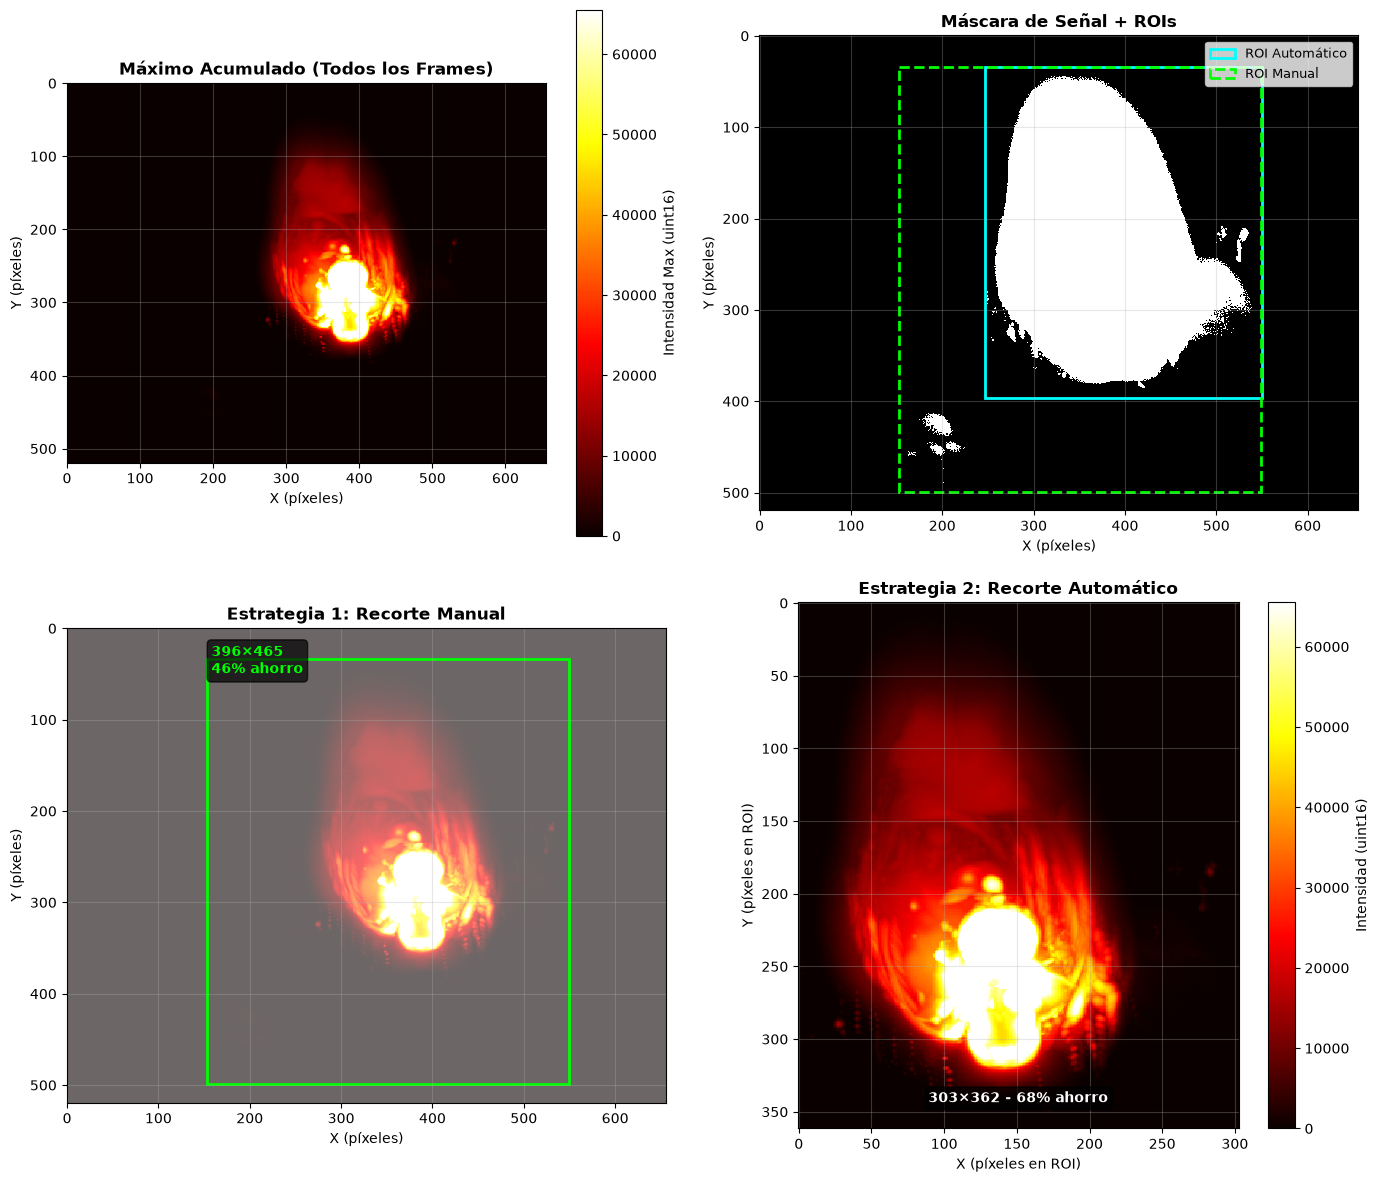

✓ Figura guardada: 04_estrategias_recorte.png


In [126]:
# === VISUALIZACIÓN DE RECORTES ===

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Máximo acumulado original
ax = axes[0, 0]
im0 = ax.imshow(maximo_acumulado, cmap='hot', interpolation='nearest')
ax.set_title('Máximo Acumulado (Todos los Frames)', fontsize=12, fontweight='bold')
ax.set_xlabel('X (píxeles)')
ax.set_ylabel('Y (píxeles)')
plt.colorbar(im0, ax=ax, label='Intensidad Max (uint16)')

# Máscara de señal con ROI automático
ax = axes[0, 1]
ax.imshow(mascara_señal.astype(int), cmap='gray', interpolation='nearest')
# Marcar ROI automático
rect_auto = plt.Rectangle((x_auto, y_auto), w_auto, h_auto, 
                           linewidth=2, edgecolor='cyan', facecolor='none', label='ROI Automático')
# Marcar ROI manual
rect_manual = plt.Rectangle((x_min, y_min), ancho_roi_manual, alto_roi_manual, 
                            linewidth=2, edgecolor='lime', facecolor='none', linestyle='--', label='ROI Manual')
ax.add_patch(rect_auto)
ax.add_patch(rect_manual)
ax.set_title('Máscara de Señal + ROIs', fontsize=12, fontweight='bold')
ax.set_xlabel('X (píxeles)')
ax.set_ylabel('Y (píxeles)')
ax.legend(loc='upper right', fontsize=9)

# Imagen con ROI manual
ax = axes[1, 0]
ax.imshow(maximo_acumulado, cmap='hot', interpolation='nearest', alpha=0.6)
rect_manual2 = plt.Rectangle((x_min, y_min), ancho_roi_manual, alto_roi_manual, 
                            linewidth=2, edgecolor='lime', facecolor='none')
ax.add_patch(rect_manual2)
ax.set_title('Estrategia 1: Recorte Manual', fontsize=12, fontweight='bold')
ax.set_xlabel('X (píxeles)')
ax.set_ylabel('Y (píxeles)')
ax.text(x_min + 5, y_min + 15, f'{ancho_roi_manual}×{alto_roi_manual}\n{ahorro_1:.0f}% ahorro', 
        color='lime', fontsize=10, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))

# Imagen recortada automática
ax = axes[1, 1]
im_recort = ax.imshow(maximo_recortado_auto, cmap='hot', interpolation='nearest')
ax.set_title('Estrategia 2: Recorte Automático', fontsize=12, fontweight='bold')
ax.set_xlabel('X (píxeles en ROI)')
ax.set_ylabel('Y (píxeles en ROI)')
ax.text(0.5, 0.05, f'{w_auto}×{h_auto} - {ahorro_2:.0f}% ahorro', 
        transform=ax.transAxes, ha='center',
        color='white', fontsize=10, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))
plt.colorbar(im_recort, ax=ax, label='Intensidad (uint16)')

plt.tight_layout()
plt.savefig(output_dir / '04_estrategias_recorte.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Figura guardada: 04_estrategias_recorte.png")

**Definición Estrategia**: Como equipo, se selecciona el recorte automático mediante un ROI calculado a partir del máximo acumulado de todos los frames, complementado con el filtrado de frames fuera de los períodos de deposición. Esta estrategia permite reducir el área de las imágenes en 67,8 %, conservando el 98,9 % de los píxeles definidos como señal, y automatiza la selección del ROI de forma reproducible. **Aunque presenta una pérdida del 1,1 % respecto al recorte manual, ofrece una reducción espacial significativamente mayor y mejora la eficiencia y escalabilidad del procesamiento.**

### PROCESAR Y GUARDAR IMÁGENES RECORTADAS

In [129]:
def procesar_frame(archivo_path):
    imagen_original = leer_imagen_tiff(archivo_path)

    # ROI automático de la Estrategia 2
    imagen_recortada = imagen_original[
        y_auto:y_auto + h_auto,
        x_auto:x_auto + w_auto
    ]

    nombre_salida = f'recortada_{archivo_path.name}'
    ruta_salida = output_images_dir / nombre_salida

    Image.fromarray(imagen_recortada, mode='I;16').save(ruta_salida)

    resultado = {
        'archivo_original': archivo_path.name,
        'archivo_recortado': nombre_salida,
        'tamano_original_KB': imagen_original.nbytes / 1024,
        'tamano_recortado_KB': imagen_recortada.nbytes / 1024,
        'ahorro_porcentaje': 100 * (
            1 - imagen_recortada.size / imagen_original.size
        )
    }

    return resultado

Se propone paralelizar el procesamiento del recorte de imágenes debido al alto volumen de datos (41.645 archivos TIFF) y a que cada frame puede procesarse de manera independiente. El uso de múltiples workers permite ejecutar concurrentemente la lectura, recorte y escritura de diferentes imágenes, reduciendo el tiempo de ejecución respecto al procesamiento secuencial. Esta optimización mejora la eficiencia del procesamiento batch y facilita su escalabilidad ante volúmenes mayores de imágenes.

In [ ]:
print('\n--- PROCESAMIENTO BATCH PARALELO ---')
print(f'Recortando {len(archivos_tiff)} imágenes con la Estrategia 2...\n')

frames_procesados = []

with ThreadPoolExecutor(max_workers=8) as executor:

    futuros = [
        executor.submit(procesar_frame, archivo)
        for archivo in archivos_tiff
    ]

    for i, futuro in enumerate(as_completed(futuros), 1):
        frames_procesados.append(futuro.result())

        if i % max(1, len(archivos_tiff) // 10) == 0 or i == len(archivos_tiff):
            print(f'  [{i:5d}/{len(archivos_tiff)}] Procesado')

print(f"\n✓ {len(frames_procesados)} imágenes recortadas")
print(f"✓ Guardadas en: {output_images_dir}")


--- PROCESAMIENTO BATCH PARALELO ---
Recortando 41645 imágenes con la Estrategia 2...

  [ 4164/41645] Procesado
  [ 8328/41645] Procesado
  [12492/41645] Procesado
  [16656/41645] Procesado
  [20820/41645] Procesado
  [24984/41645] Procesado
  [29148/41645] Procesado
  [33312/41645] Procesado
  [37476/41645] Procesado
  [41640/41645] Procesado
  [41645/41645] Procesado

✓ 41645 imágenes recortadas
✓ Guardadas en: C:\Users\noeli\OneDrive\Documentos\CursoIA\Data\outputs\imagenes_procesadas


### REPORTE DE IMÁGENES PROCESADAS

In [131]:
# Crear DataFrame con información de imágenes procesadas
df_procesadas = pd.DataFrame(frames_procesados)

print(f"\n=== RESUMEN DE IMÁGENES PROCESADAS ===")
print(f"\n{df_procesadas.to_string(index=False)}")

print(f"\n--- Estadísticas Globales ---")
print(f"Tamaño total original: {df_procesadas['tamano_original_KB'].sum():.1f} KB")
print(f"Tamaño total recortado: {df_procesadas['tamano_recortado_KB'].sum():.1f} KB")
print(f"Ahorro promedio por frame: {df_procesadas['ahorro_porcentaje'].mean():.1f}%")
print(f"Ahorro total: {100*(df_procesadas['tamano_original_KB'].sum() - df_procesadas['tamano_recortado_KB'].sum())/df_procesadas['tamano_original_KB'].sum():.1f}%")

# Guardar reporte en CSV
reporte_imagenes = output_dir / 'reporte_imagenes_procesadas.csv'
df_procesadas.to_csv(reporte_imagenes, index=False)
print(f"\n✓ Reporte guardado: {reporte_imagenes}")


=== RESUMEN DE IMÁGENES PROCESADAS ===

  archivo_original            archivo_recortado  tamano_original_KB  tamano_recortado_KB  ahorro_porcentaje
1764596703148.tiff recortada_1764596703148.tiff              666.25           214.230469          67.845333
1764596703333.tiff recortada_1764596703333.tiff              666.25           214.230469          67.845333
1764596703311.tiff recortada_1764596703311.tiff              666.25           214.230469          67.845333
1764596703259.tiff recortada_1764596703259.tiff              666.25           214.230469          67.845333
1764596703081.tiff recortada_1764596703081.tiff              666.25           214.230469          67.845333
1764596703103.tiff recortada_1764596703103.tiff              666.25           214.230469          67.845333
1764596703044.tiff recortada_1764596703044.tiff              666.25           214.230469          67.845333
1764596703325.tiff recortada_1764596703325.tiff              666.25           214.230469       

---

## Resumen Final y Comentario de Aprendizaje

In [134]:
print(f"\nARCHIVOS GENERADOS EN: {output_dir}\n")

for ext, titulo in [('csv', 'CSV'), ('json', 'JSON'), ('png', 'PNG')]:
    archivos = sorted(output_dir.glob(f'*.{ext}'))
    print(f"{titulo}:")
    for archivo in archivos:
        print(f"  ✓ {archivo.name} ({archivo.stat().st_size / 1024:.1f} KB)")


ARCHIVOS GENERADOS EN: C:\Users\noeli\OneDrive\Documentos\CursoIA\Data\outputs

CSV:
  ✓ datos_sincronizados_v2.csv (16431.5 KB)
  ✓ reporte_imagenes_procesadas.csv (3497.6 KB)
JSON:
  ✓ registro_procesamiento.json (2.1 KB)
PNG:
  ✓ 01_trayectoria_3d.png (270.0 KB)
  ✓ 02_distribucion_intervalos_tiempo.png (235.3 KB)
  ✓ 03_diferencias_timestamps.png (96.2 KB)
  ✓ 04_estrategias_recorte.png (346.5 KB)


### Comentario Final

La realización de este trabajo permitió al equipo **afianzar lo aprendido en clase** y llevarlo a un caso práctico, entendiendo mejor cómo analizar, procesar y reducir imágenes de manera técnica. También nos permitió reconocer que estas decisiones no solo buscan reducir datos, sino **conservar la información relevante y optimizar los recursos disponibles**. Esto es especialmente importante en proyectos reales con grandes volúmenes de imágenes, donde el costo computacional hace necesario encontrar un equilibrio entre **calidad, eficiencia y costo-beneficio**.